# Turbulence synthesis: MGD and MGD regularised (Guth method) 

This notebook runs the 1D turbulence synthesis experiment and compares MGD theta trajectories with the regularised trajectories. 


In [1]:
import torch
import numpy as np
import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import stats, ndimage

import sys
from pathlib import Path

import hashlib
from datetime import datetime
from types import SimpleNamespace

root = Path.cwd()
print(root)

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import *
from utils_experiment import * 
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

root = Path.cwd()
print(root) 

/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence
device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


## Data preprocessing

In [2]:
# Orthogonal wavelet
W = DefineWavelet('Db', m=3, device=device)

Data = load_turbulence_1d()
print(Data.shape) 

n = 1024
Data = split_periodize_reshape(Data, n)

#B, C, L = Data.shape
#Data = Data.view(B * 2, C, L // 2)
#print(Data.shape) 

# Same preprocessing as in the original notebook.
for j in range(3):
    Data = W.decompose(Data)[1]

n1 = 1000
x1 = normalize(Data[:n1]).to(device) # choose here if you want less data 
print('Data shape after preprocessing:', Data.shape)
print('x1 shape:', x1.shape) 

torch.Size([10000, 1, 1800])
Data shape after preprocessing: torch.Size([10000, 1, 128])
x1 shape: torch.Size([1000, 1, 128])


## Shared model/SDE parameters

In [11]:
B, channels, M = x1.shape
print(f'(B, C, T) = ({B}, {channels}, {M}).')

J = 7
Q = 3

filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
filters_Q = return_Filters(M, J, Q, device=device)

print("filters shape:", filters.shape) 
print("filters_Q shape:", filters_Q.shape) 

interpolant = 'Cos'
nt = 10

# originally 50000
t = 1 - (1 - torch.linspace(0, 1, nt + 1))**2  # LINEAR SCHEDULE 
sigma = 3.5 

nb_workers = x1.shape[0]
nb_interpolants = x1.shape[0]
batch_size = x1.shape[0] 
regularization = 1e-2

n_subsample = 150
lam = 1e-6

seed = 200 

terms = [
    # "L_6",
    #"L_6_psi", 
    # "L_2_lowpass",
    "Scattering_Fourth_Order_Mod2_Real_Q1",
    #"Scattering_Fourth_Order_Mod2_Imag_Q1",
    #"Scalar_psi_gaussianK",
    #"Scalar_morlet_gaussianK", 

]

timestamp= datetime.now().strftime("%Y%m%d_%H%M")

FORCE_RERUN = False
SAVE_AUX_MOMENTS = True

label = ""

args = SimpleNamespace(
       Re_number=None, timestamp=timestamp, label=label,
       J=J, Q=Q, terms=terms,
       nt=nt, sigma=sigma, interpolant=interpolant,
       regularization=regularization, lam=lam, n_subsample=n_subsample,
       batch_size=None, force_rerun=FORCE_RERUN, no_save_aux_moments=not SAVE_AUX_MOMENTS,
       n_traj_groups=5, n_tau=30, moment_threshold=1e-8, n1=x1.shape[0], seed=seed,
   )

config = build_config_name(args, M, coarse_grained=False, include_timestamp=True)
log_dir = root / 'saved_results/logs'
exp_dir = root / 'saved_results' / 'experiments' / config
fig_dir = exp_dir / 'figures'
exp_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
logger = setup_logging(log_dir, config)

(B, C, T) = (1000, 1, 128).
filters shape: torch.Size([1, 8, 128])
filters_Q shape: torch.Size([1, 22, 128])


## save wavelet coefficients 

## Check wavelet coefficients histograms, Q=3

torch.Size([5000, 22, 128])


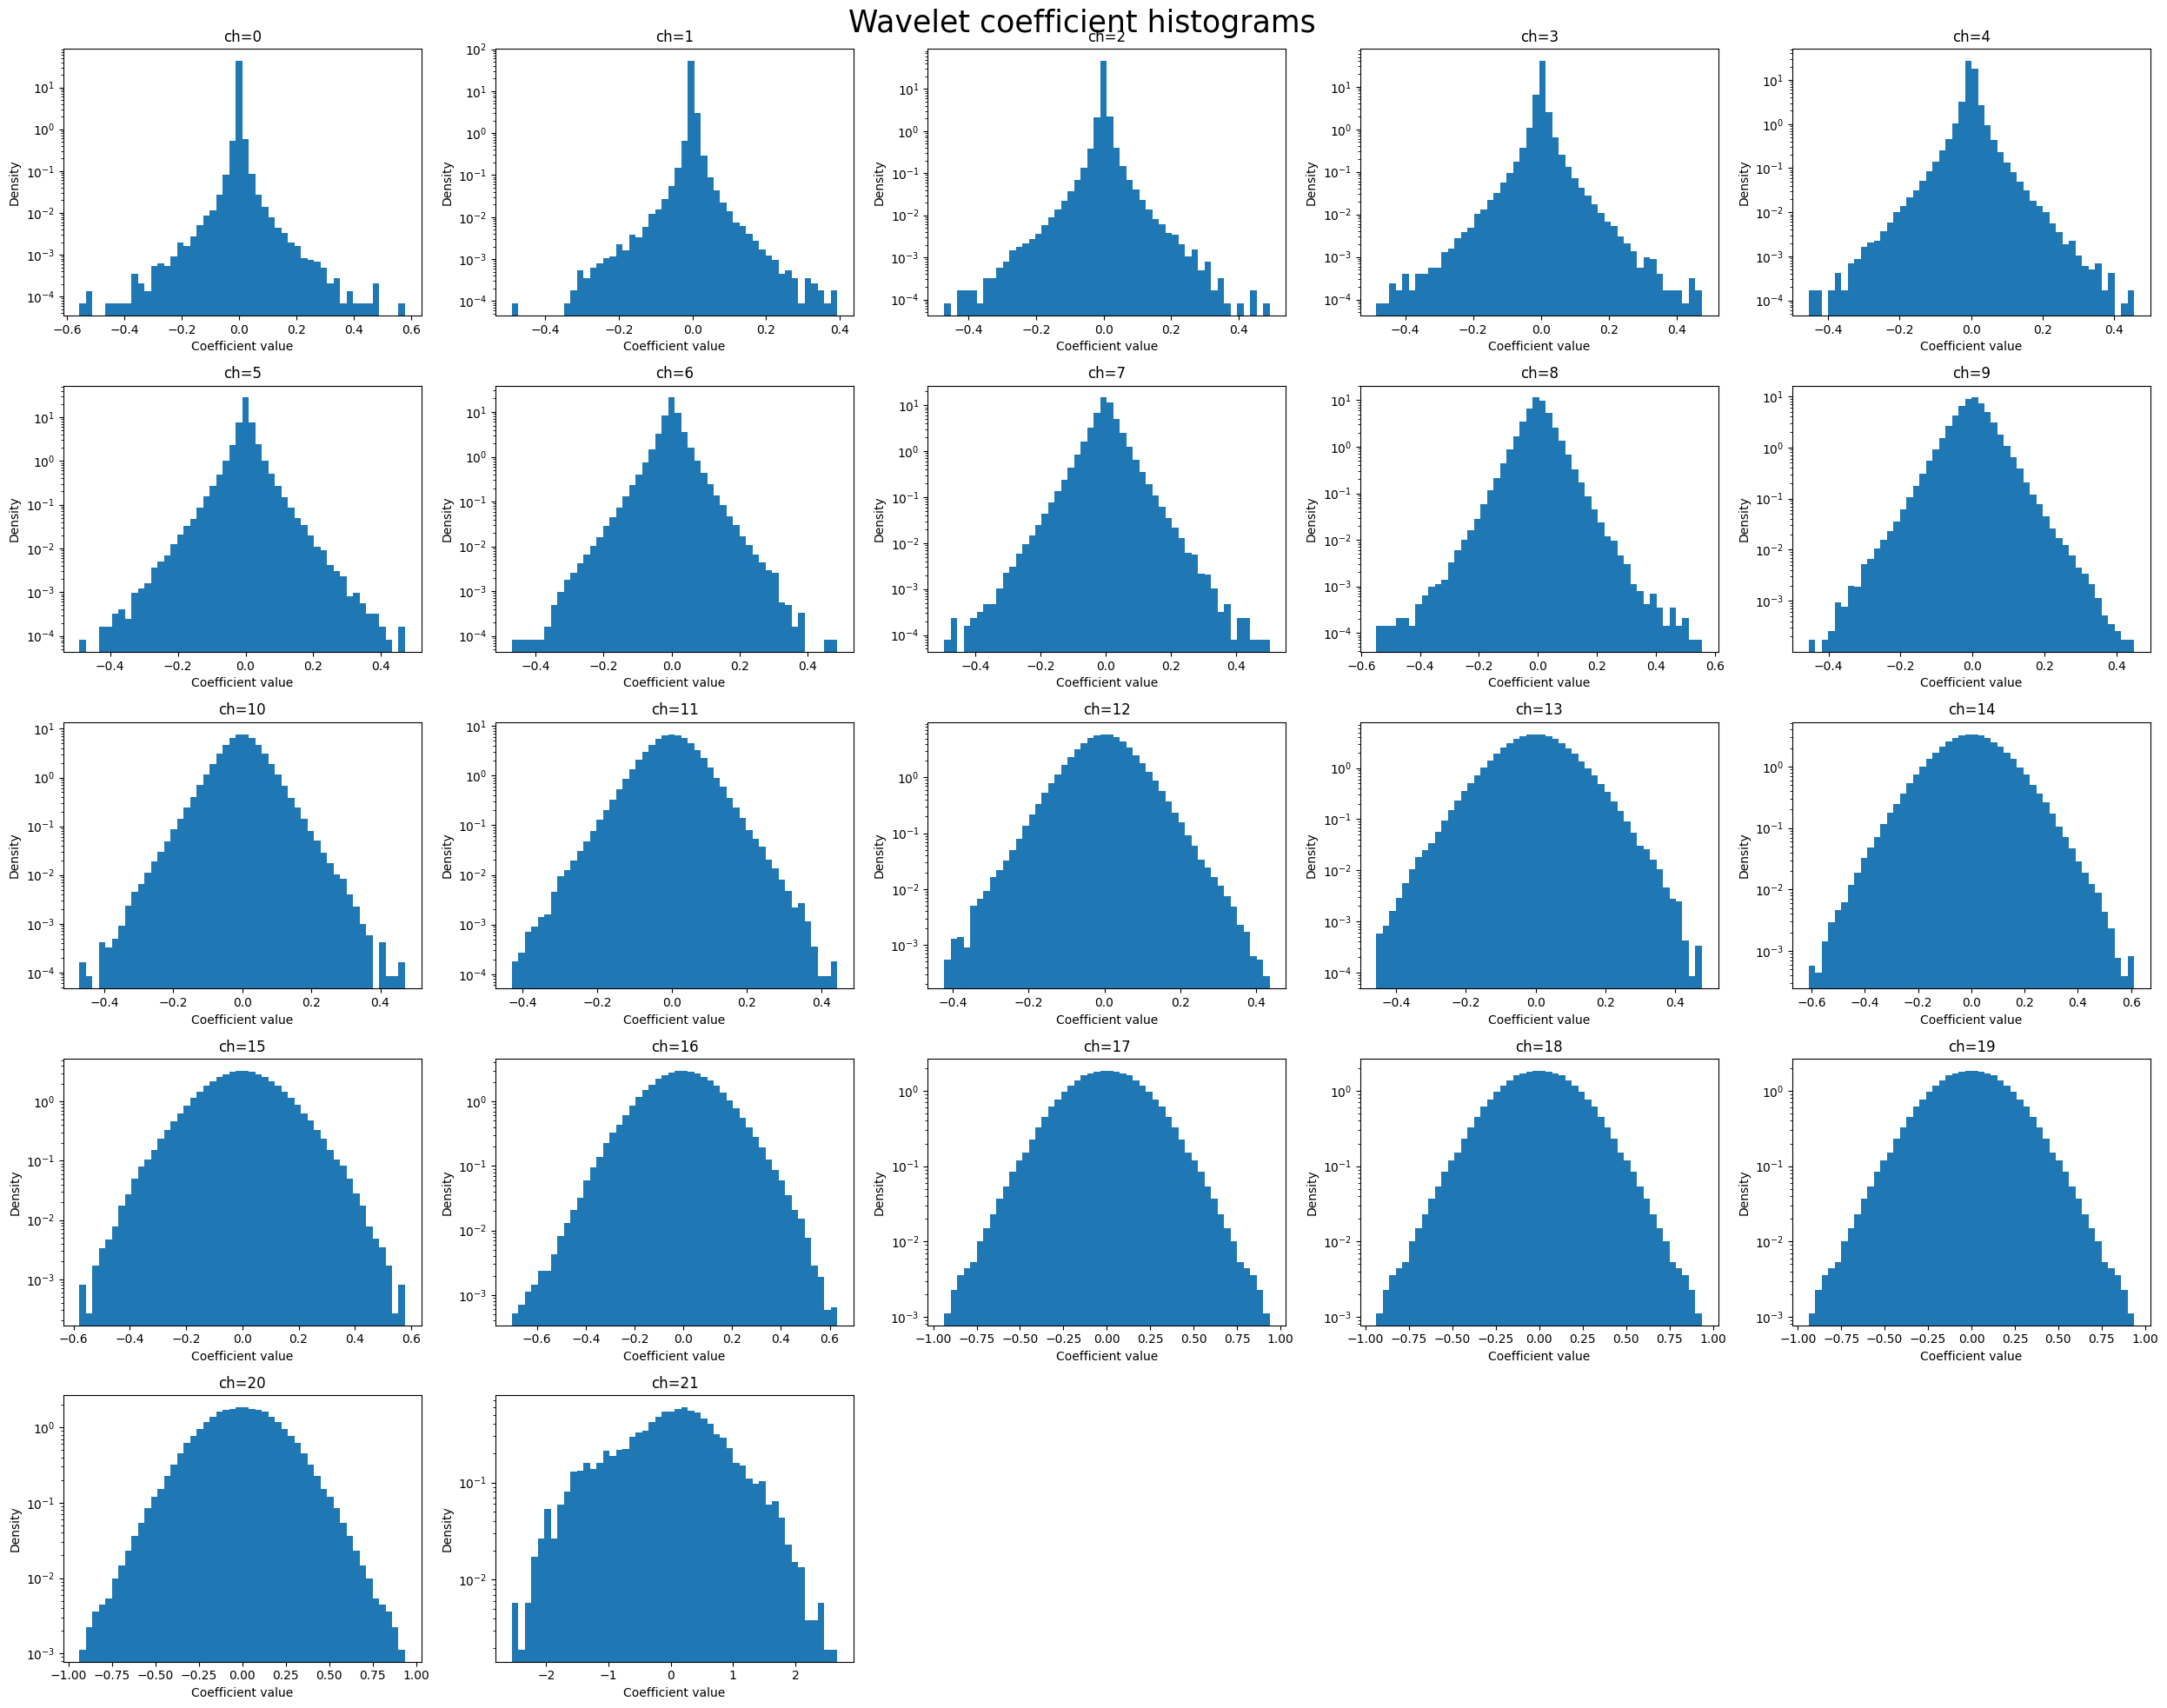

In [23]:
%matplotlib inline 
wt = torch.fft.ifft(torch.fft.fft(x1) * filters_Q).real  # (B, J, T)
print(wt.shape) 
n_wavelets = filters_Q.shape[1]
# ------------------------------------------------------------------
# 1. Overview grid
# ------------------------------------------------------------------
ncols = 5
nrows = math.ceil(n_wavelets / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
for i in range(n_wavelets):
    vals = wt[:, i, :].detach().cpu().flatten().numpy()
    axes[i].hist(vals, bins=50, density=True, log=True)
    axes[i].set_title(f"ch={i}")
    axes[i].set_xlabel("Coefficient value")
    axes[i].set_ylabel("Density")
for j in range(n_wavelets, len(axes)):
    axes[j].axis("off")
plt.suptitle(f"Wavelet coefficient histograms", fontsize=25)
plt.tight_layout()
plt.show()

## Run or load an experiment

Set `FORCE_RERUN = True` if you want to recompute samples even when saved results already exist.

The standard outputs are saved with your existing `save_results(...)`. In addition, this notebook saves a small auxiliary `.pt` file containing `barphi_e` and `barphi_p`, because these are useful for plotting moment matching after reloading.


## Define and run experiments 

In [5]:
t[-145:]

tensor([0.9999, 0.9999, 0.9999, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 

In [12]:
potentials_dir = exp_dir / 'fitted_potentials'
result = run_experiment(args, M, config, x1, filters, t[:-145], 
                        logger, root, device=device, 
                        filters_Q=filters_Q, filters_Phi=filters_Phi, 
                        potentials_save_dir=potentials_dir,
                       ) 

2026-07-28 11:13:21  INFO      Running experiment: turbulencesynth_M128_J7_Q3_sigma3.5_nt10_n1_1000_lam1e-06_seed_200_termsec1eec51_20260728_1113
2026-07-28 11:13:21  INFO      terms: ['Scattering_Fourth_Order_Real_Q1']
Signal detected as 1D: (B, C, T) = (1000, 1, 128).
The model has 56 potentials.
The model has 56 potentials.


0it [00:00, ?it/s]


Loop finished
After loop: CPU=1.01 GB | GPU alloc=0.01 GB | GPU reserved=0.53 GB
Preparing regularised solve
Before _solve_regularised: CPU=1.01 GB | GPU alloc=0.00 GB | GPU reserved=0.53 GB


<class 'IndexError'>: index 0 is out of bounds for axis 0 with size 0

In [15]:
# save reg thetas 
theta_reg_t = result['Theta_reg']
theta_reg_t.shape 

torch.Size([63, 79])

## Check fits 

Total potential features: 311
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-16205911  K2=-16326488  K3=-16348547  K4=-16349085)
[GGD^4][ch 0] Keff=4  cuts=[0.0002 0.0007 0.0054]  pi=[45.8% 44.0% 9.7% 0.5%]  alpha=[1.96 0.79 0.41 0.41]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-16491472  K2=-16634391  K3=-16660426  K4=-16661796)
[GGD^4][ch 1] Keff=4  cuts=[0.0002 0.0006 0.0070]  pi=[66.9% 22.7% 9.9% 0.5%]  alpha=[1.61 0.41 0.39 0.41]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-15401259  K2=-15555130  K3=-15569726  K4=-15573686)
[GGD^4][ch 2] Keff=4  cuts=[0.0003 0.0012 0.0131]  pi=[66.4% 23.1% 9.9% 0.6%]  alpha=[1.49 0.38 0.37 0.41]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-14014799  K2=-14124933  K3=-14137468  K4=-14140422)
[GGD^4][ch 3] Keff=4  cuts=[0.0005 0.0026 0.0258]  pi=[66.0% 23.4% 10.0% 0.6%]  alpha=[1.19 0.35 0.38 0.42]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-12338997  K2=-12385589  K3=-12395560  K4=-1

/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence/../codes/potentials/potentials_1d.py:1073: RuntimeWarning: overflow encountered in cast
  logpdf = (np.log(a) - np.log(2.0) - np.log(s) - gammaln(1.0 / a) - (ah / s) ** a)


    [model-select] chose K=3  (Kmax=4)  (BIC: K1=3046326  K2=3033563  K3=3030223  K4=3030240)
[GGD^4][ch 24] Keff=3  cuts=[0.0000 0.3074 1.3191]  pi=[0.0% 32.2% 56.3% 11.5%]  alpha=[1.00 4.16 1.09 3.21]  active=3
[active] 82 active statistics (18 dead slots dropped before they can singularize the Gram)
[prune] dropped 81 near-collinear statistic(s); 1 remain


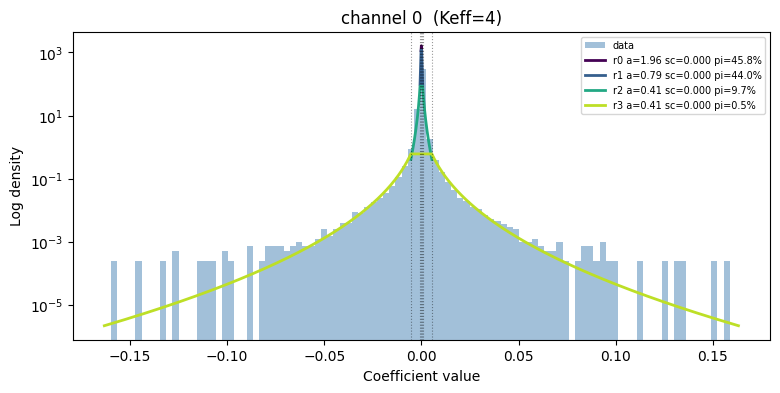

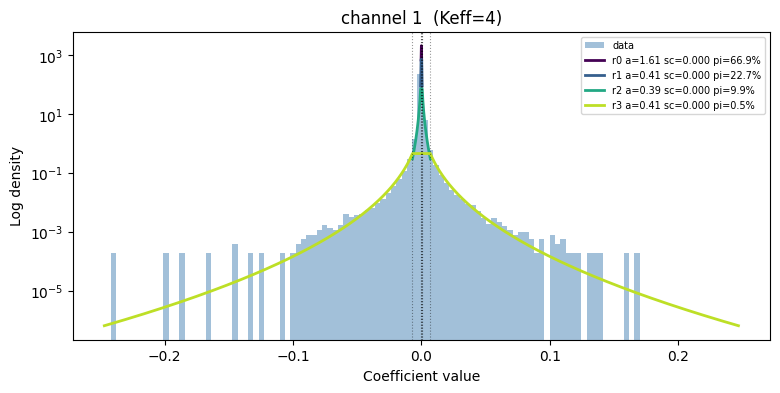

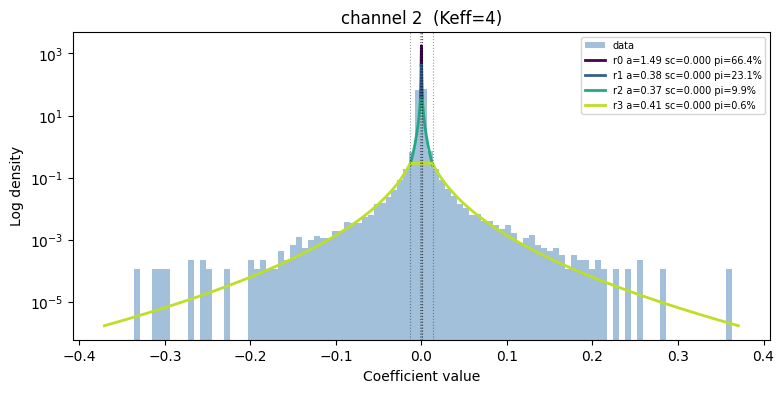

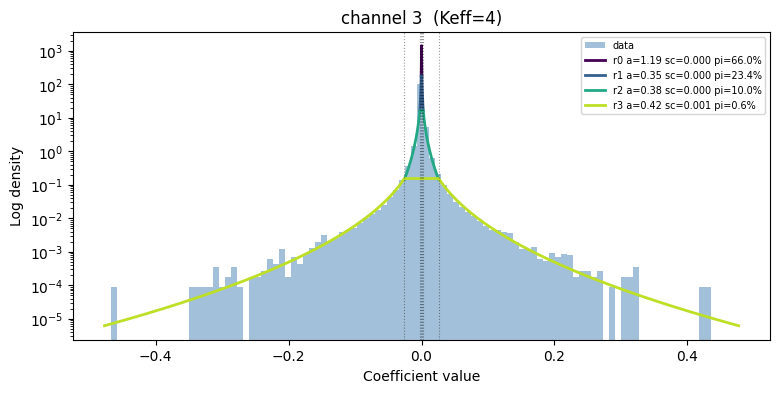

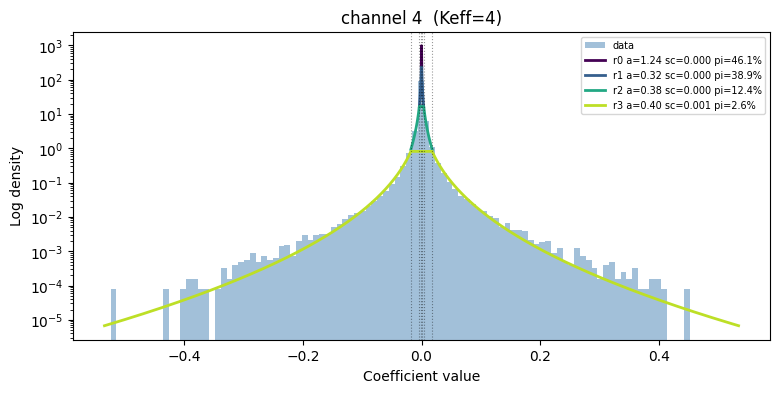

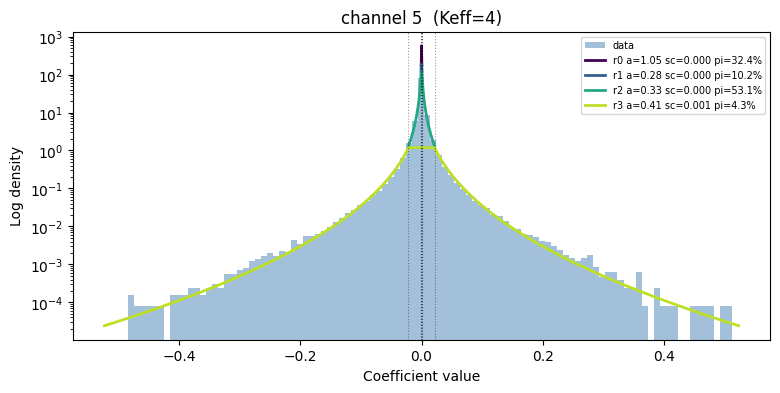

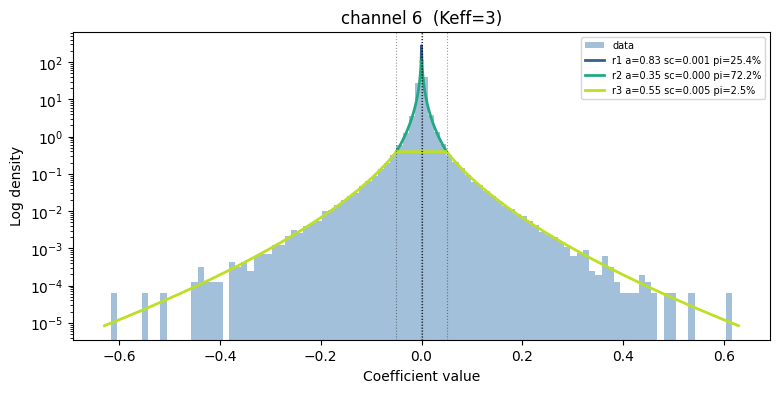

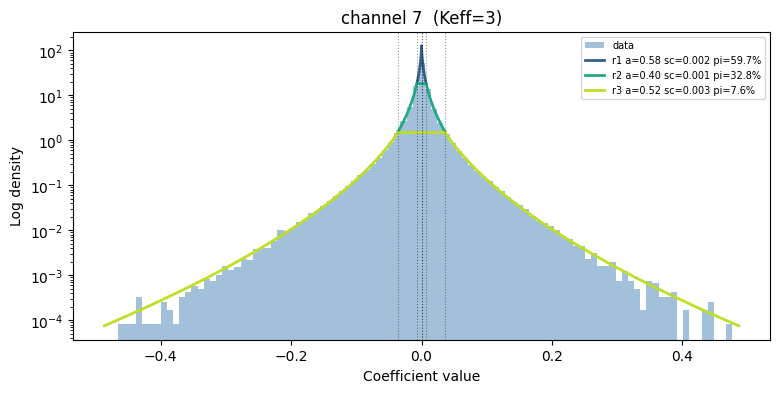

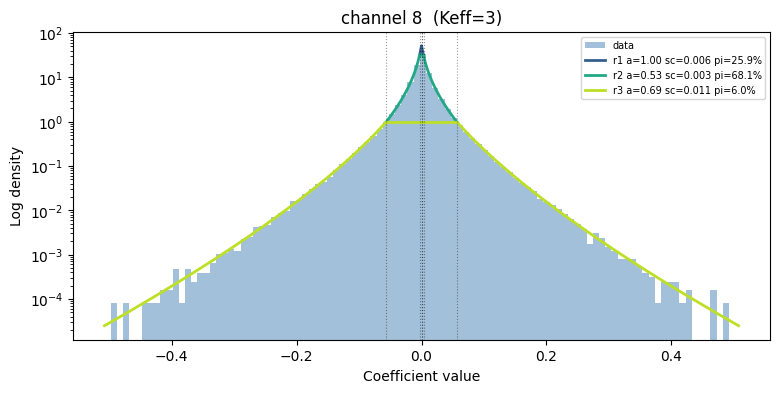

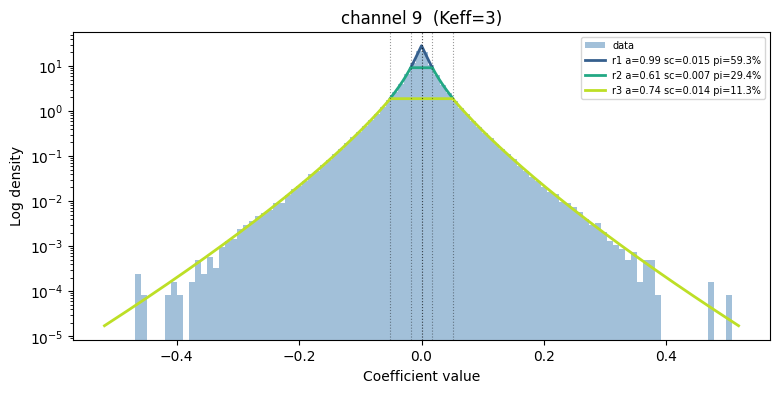

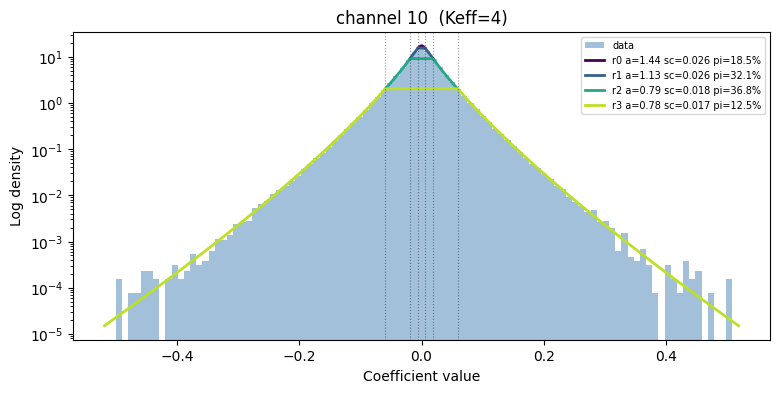

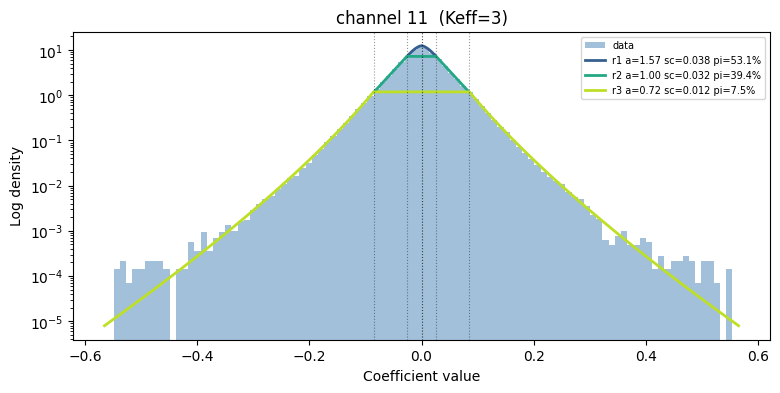

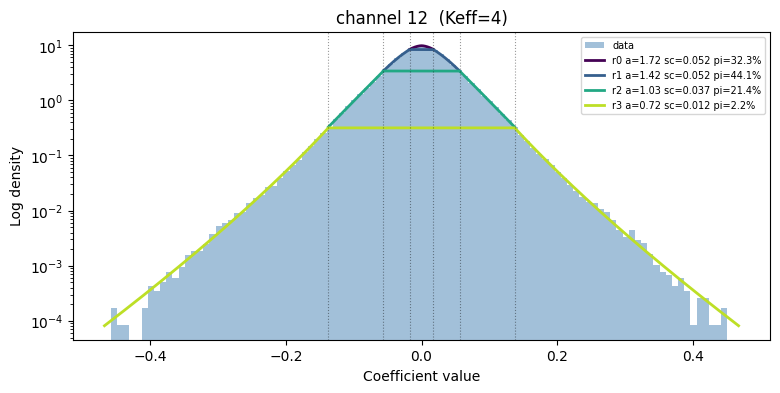

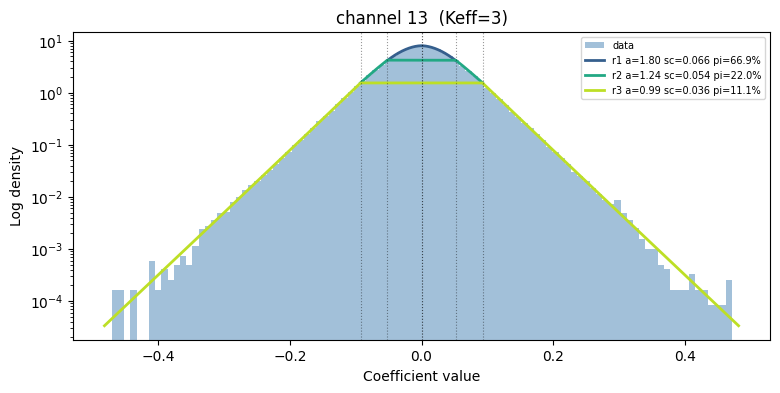

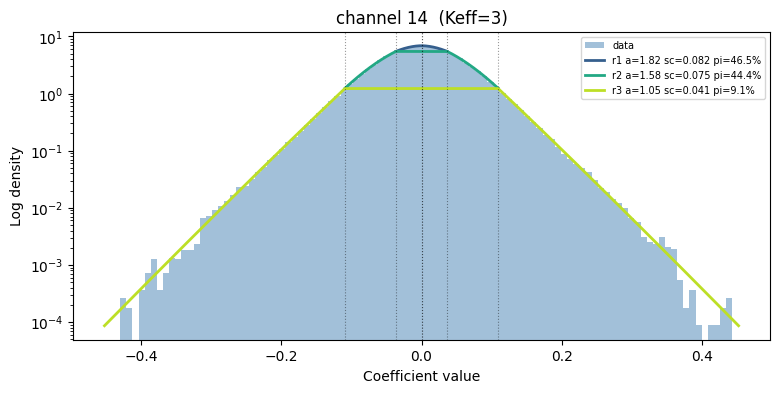

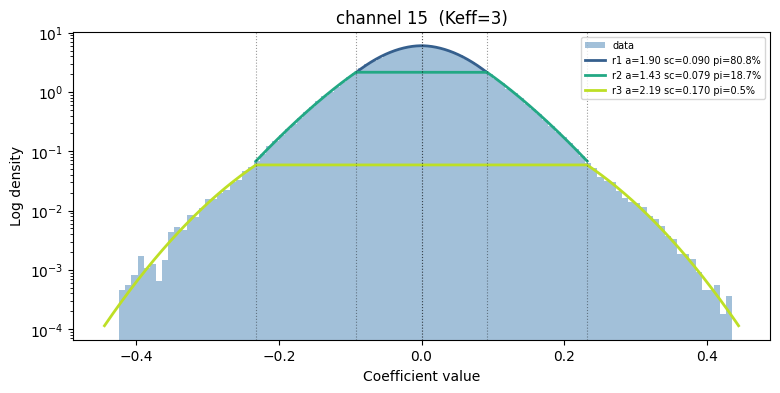

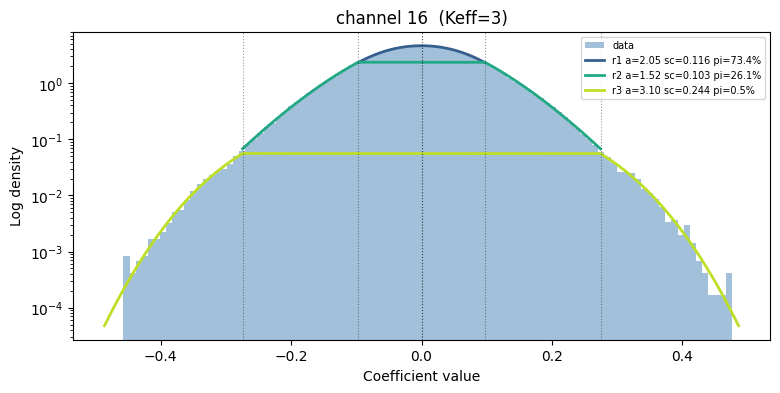

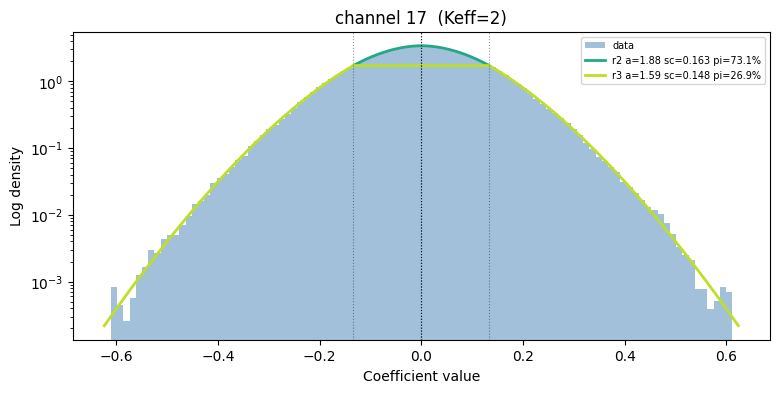

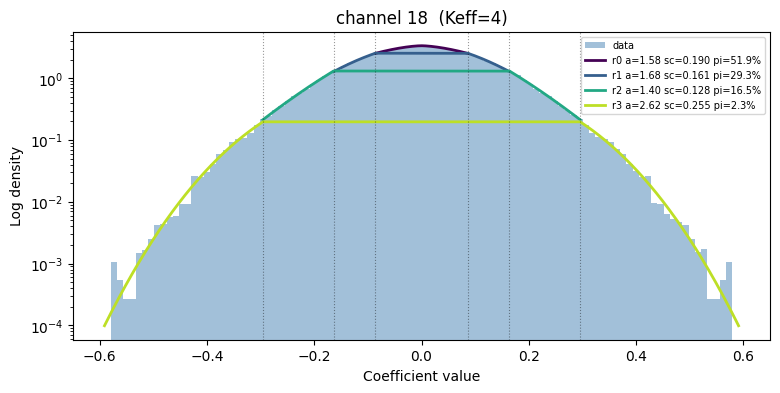

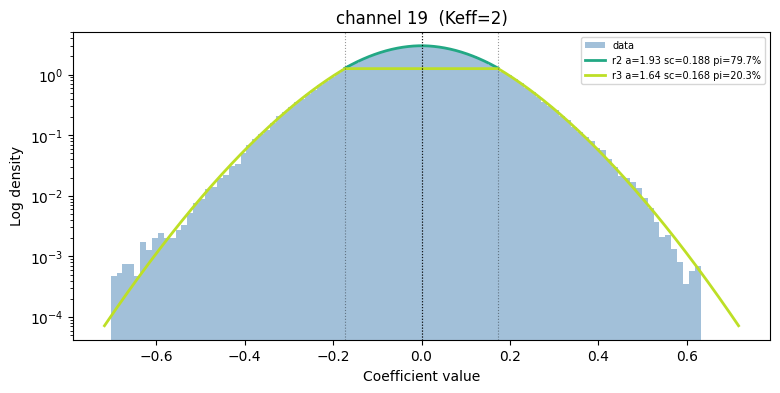

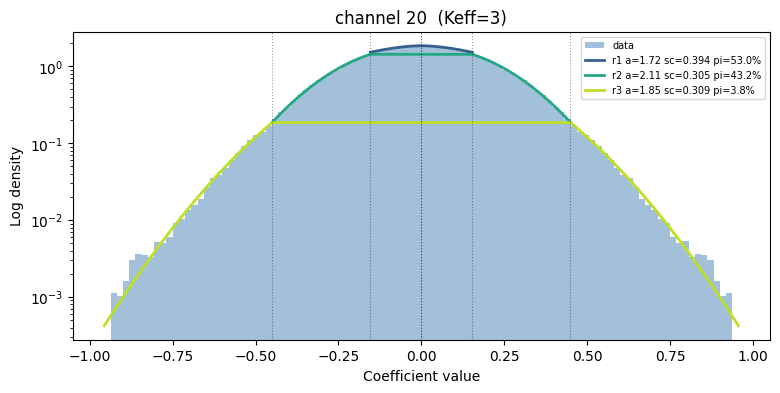

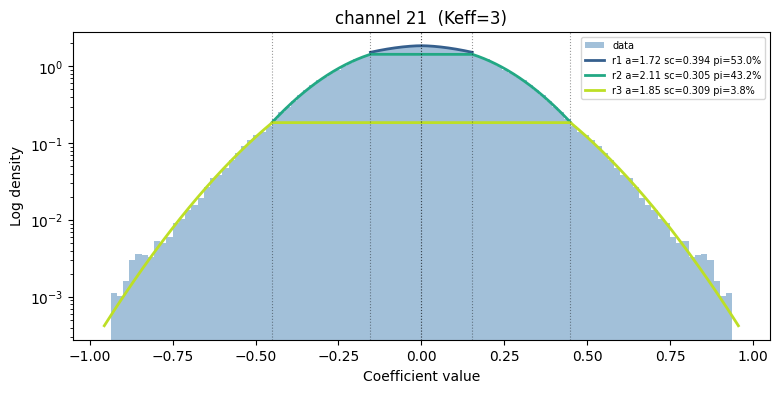

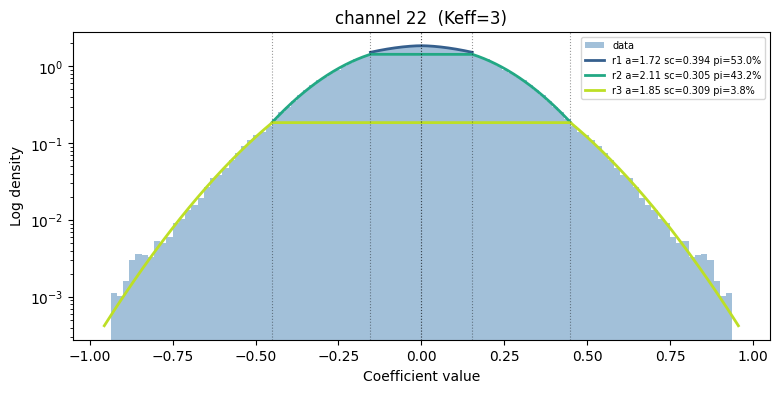

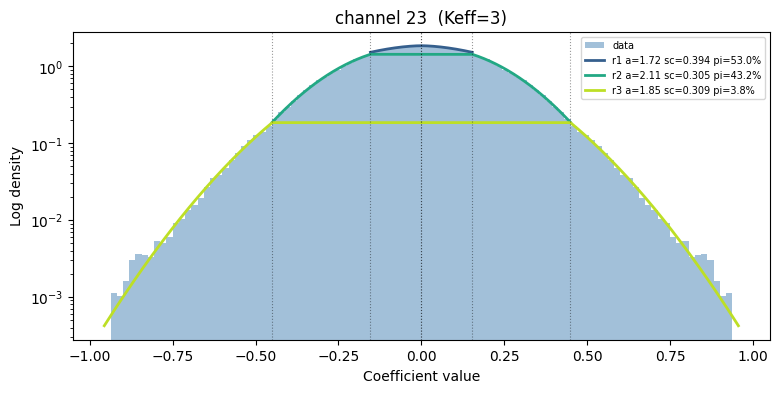

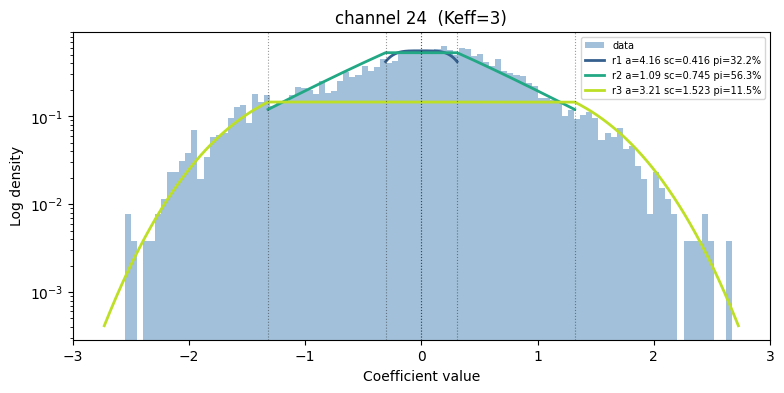

[Scalar_psi_gaussianK] fit fresh and saved: 1 active statistics
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-10834196  K2=-10892179  K3=-10901031  K4=-10902580)
[GGD^4][ch 0] Keff=4  cuts=[0.0010 0.0041 0.0199]  pi=[46.0% 35.3% 16.1% 2.6%]  alpha=[1.44 0.47 0.39 0.41]  active=4
    [model-select] chose K=3  (Kmax=4)  (BIC: K1=-9060617  K2=-9101830  K3=-9106612  K4=-9106507)
[GGD^4][ch 1] Keff=3  cuts=[0.0000 0.0016 0.0397]  pi=[0.0% 39.4% 58.1% 2.5%]  alpha=[2.13 1.33 0.34 0.42]  active=3
    [model-select] chose K=3  (Kmax=4)  (BIC: K1=-5958383  K2=-5980561  K3=-5980785  K4=-5980669)
[GGD^4][ch 2] Keff=3  cuts=[0.0000 0.0099 0.2161]  pi=[0.0% 53.1% 46.4% 0.5%]  alpha=[8.00 1.14 0.36 0.79]  active=3
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-3715210  K2=-3720936  K3=-3721454  K4=-3721479)
[GGD^4][ch 3] Keff=4  cuts=[0.0348 0.1031 0.1609]  pi=[59.6% 30.1% 6.3% 4.0%]  alpha=[1.25 0.63 0.64 0.80]  active=4
    [model-select] chose K=2  (Kmax=4)  (BIC: K1=-2448427  K2=-2451762 

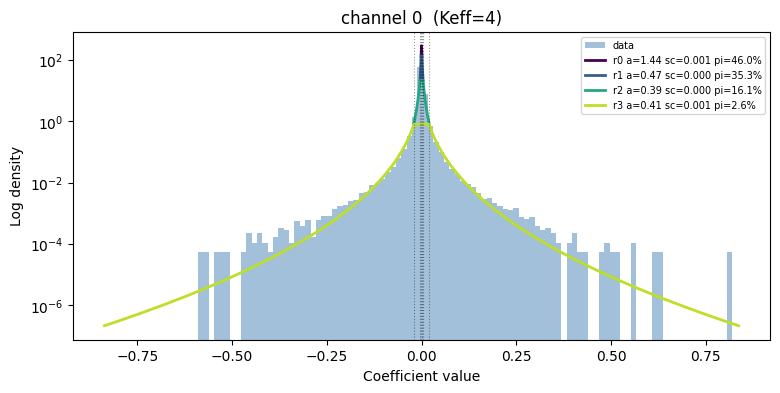

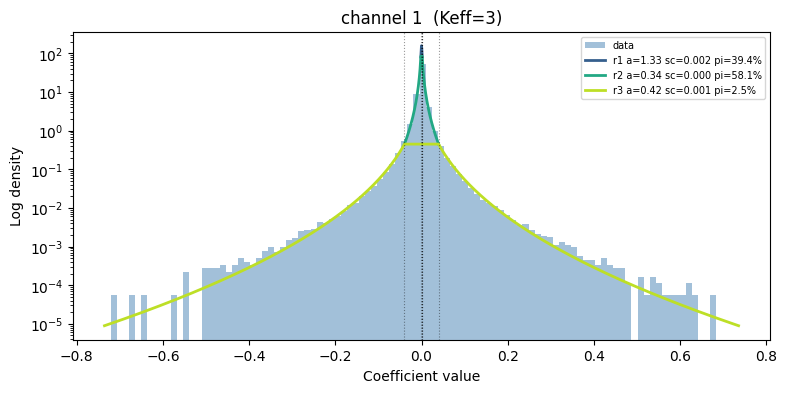

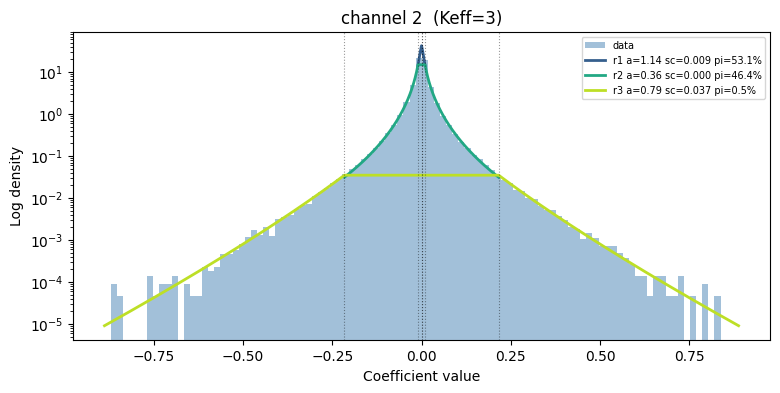

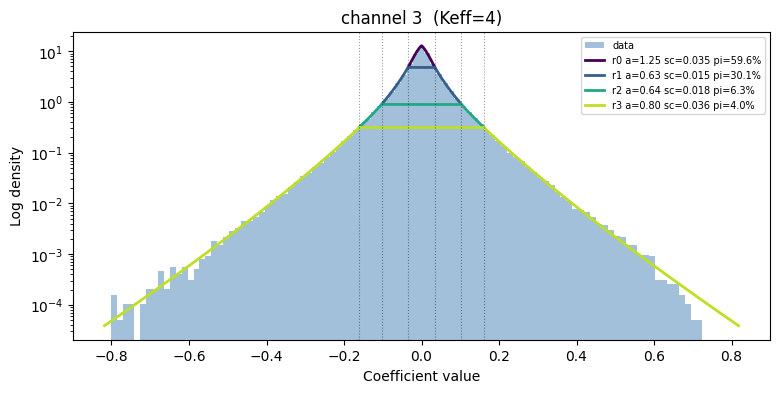

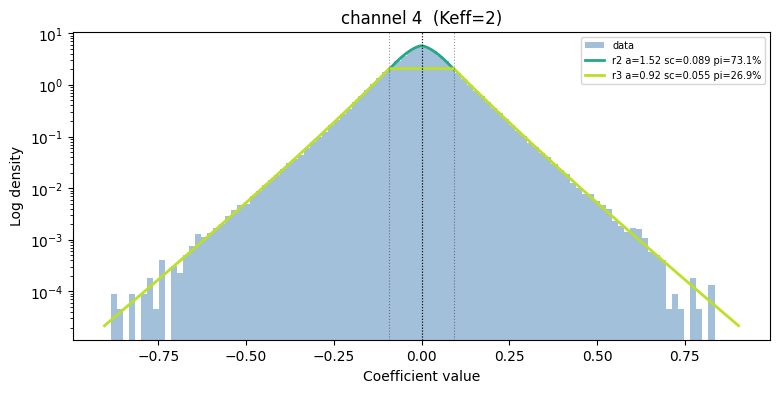

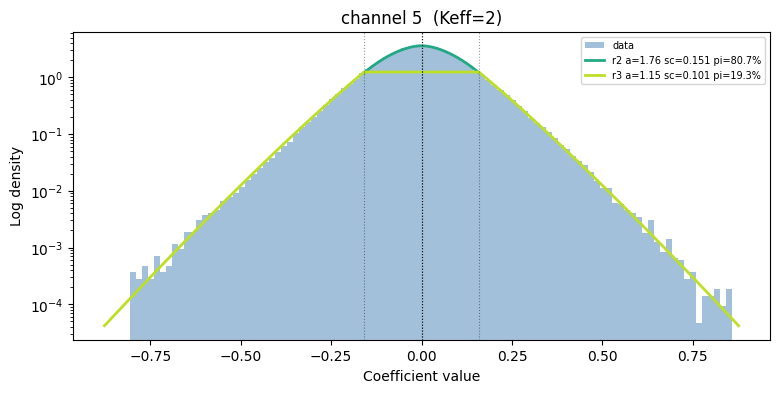

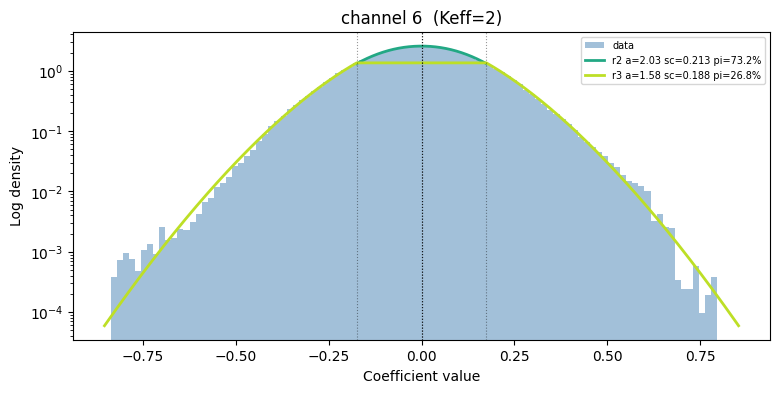

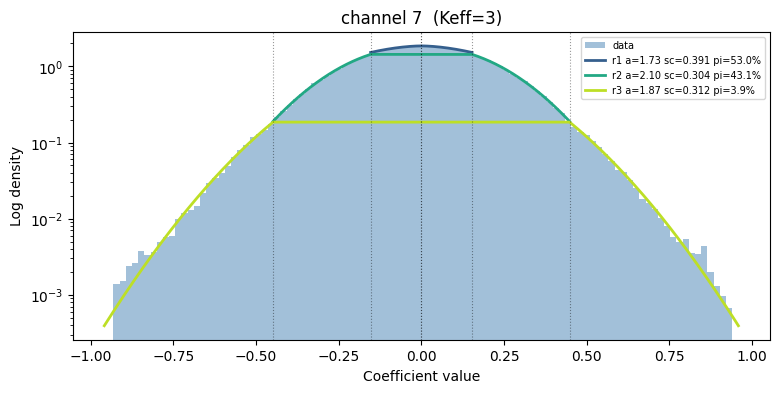

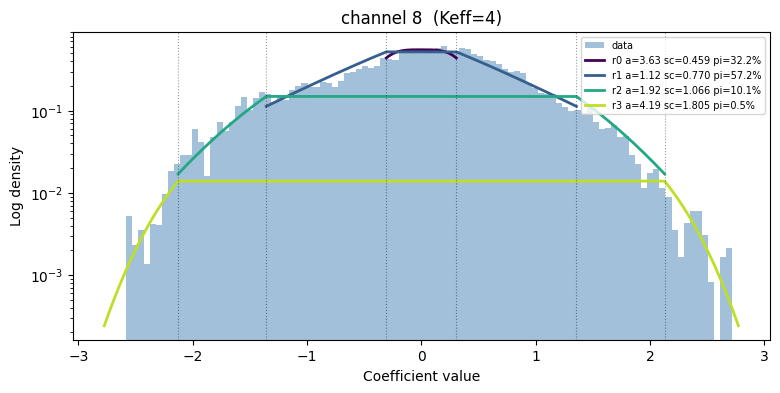

[Scalar_morlet_gaussianK] fit fresh and saved: 27 active statistics
Total potential features after fitting: 203


In [11]:
FITTED_DIR = Path("saved_results")
FITTED_DIR.mkdir(exist_ok=True, parents=True)
Q = 3

with torch.no_grad():
    filters = return_Filters(M, J, 1, device=device)
    potentials = get_1d_potentials(
        terms, J, filters, Q, filters_Q, filters_Phi,
        scalar_param=None, parallel=False,
    )
    sizes = [p.num_coefficients for p in potentials.values()]
    print(f"Total potential features: {sum(sizes)}")

    evaluated_features = []
    for name, p in potentials.items():
        p.to(device)
        state_path = FITTED_DIR / f"{name}.pt"

        if hasattr(p, "is_fitted"):
            own_filters = p.filters  # whichever bank THIS potential was built with
            if state_path.exists():
                p = type(p).load_fixed_parameters(state_path, own_filters, map_location=device)
                p.to(device)
                potentials[name] = p
                print(f"[{name}] loaded fitted state: {p.num_coefficients} active statistics")
            else:
                p.fit_reference(x1)
                p.save_fixed_parameters(state_path)
                print(f"[{name}] fit fresh and saved: {p.num_coefficients} active statistics")

        feat = p(x1)
        if feat.ndim == 1:
            feat = feat.unsqueeze(1)
        evaluated_features.append(feat)

    phi_X = torch.cat(evaluated_features, dim=-1)
    print(f"Total potential features after fitting: {phi_X.shape[-1]}")

## Fit check 

In [10]:
root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from potentials.potentials_classes.generalized_gauss_Kregions import Scalar_GGD_KRegion

In [11]:
filters = return_Filters(M, J, 1, device=device, include_phi=False)
model1= Scalar_GGD_KRegion(filters)
model1.fit_reference(x1)

    [model-select] chose K=3  (Kmax=4)  (BIC: K1=-2317987  K2=-2330567  K3=-2332021  K4=-2332016)
[GGD^4][ch 0] Keff=3  cuts=[0.0000 0.0027 0.0739]  pi=[0.0% 39.3% 58.5% 2.2%]  alpha=[1.00 1.38 0.34 0.43]  active=3
    [model-select] chose K=3  (Kmax=4)  (BIC: K1=-1858462  K2=-1865742  K3=-1865843  K4=-1865777)
[GGD^4][ch 1] Keff=3  cuts=[0.0000 0.0090 0.1079]  pi=[0.0% 53.3% 44.4% 2.3%]  alpha=[1.00 1.17 0.36 0.68]  active=3
    [model-select] chose K=3  (Kmax=4)  (BIC: K1=-1176965  K2=-1179030  K3=-1179038  K4=-1178994)
[GGD^4][ch 2] Keff=3  cuts=[0.0000 0.0169 0.2731]  pi=[0.0% 39.4% 60.0% 0.6%]  alpha=[1.00 1.61 0.60 1.23]  active=3
    [model-select] chose K=2  (Kmax=4)  (BIC: K1=-784055  K2=-785324  K3=-785288  K4=-785238)
[GGD^4][ch 3] Keff=2  cuts=[0.0000 0.0000 0.0728]  pi=[0.0% 0.0% 66.7% 33.3%]  alpha=[1.00 1.00 1.62 0.89]  active=2
    [model-select] chose K=2  (Kmax=4)  (BIC: K1=-532353  K2=-533110  K3=-533092  K4=-533040)
[GGD^4][ch 4] Keff=2  cuts=[0.0000 0.0000 0.1474] 

/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence/../codes/potentials/potentials_classes/generalized_gauss_Kregions.py:178: RuntimeWarning: overflow encountered in cast
  logpdf = (np.log(a) - np.log(2.0) - np.log(s) - gammaln(1.0 / a) - (ah / s) ** a)


    [model-select] chose K=4  (Kmax=4)  (BIC: K1=927376  K2=925707  K3=925339  K4=924882)
[GGD^4][ch 7] Keff=4  cuts=[0.5874 1.2203 1.8304]  pi=[53.1% 32.6% 12.3% 2.0%]  alpha=[8.00 1.30 0.49 1.38]  active=4
[active] 22 active statistics (10 dead slots dropped before they can singularize the Gram)
[prune] dropped 0 near-collinear statistic(s); 22 remain


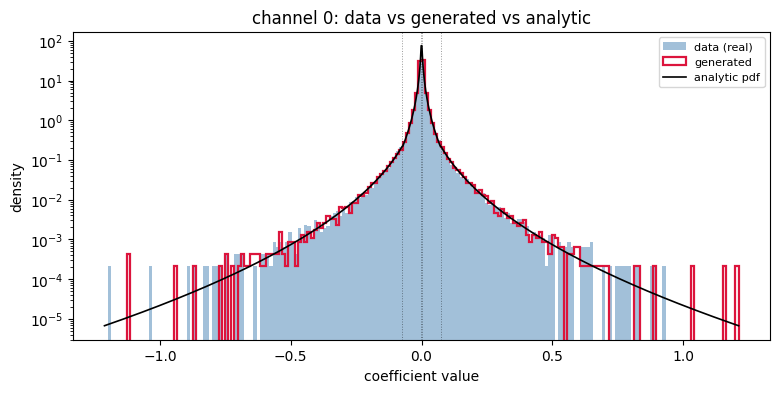

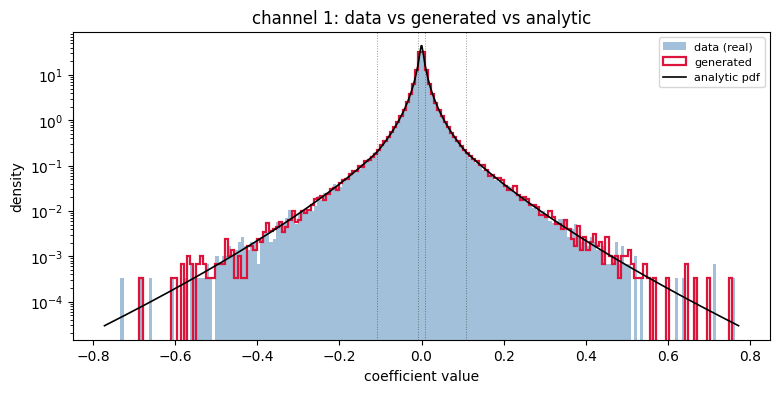

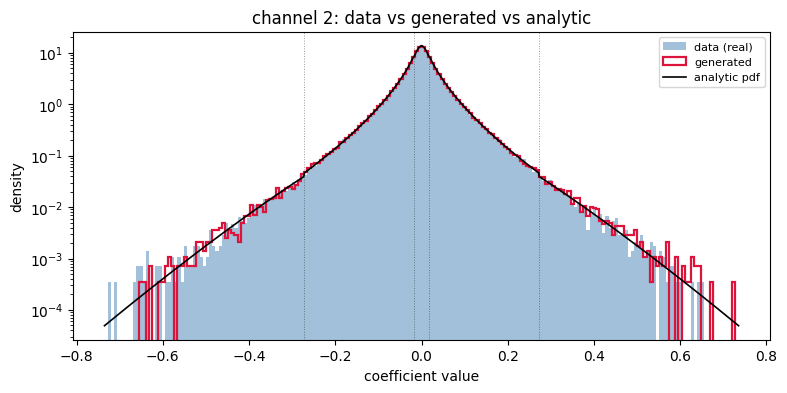

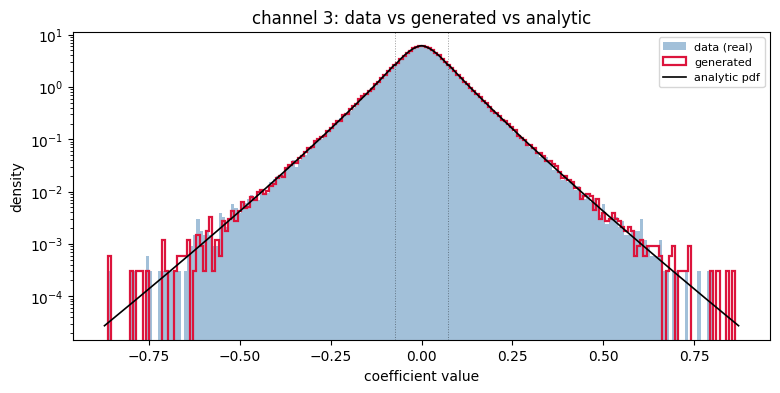

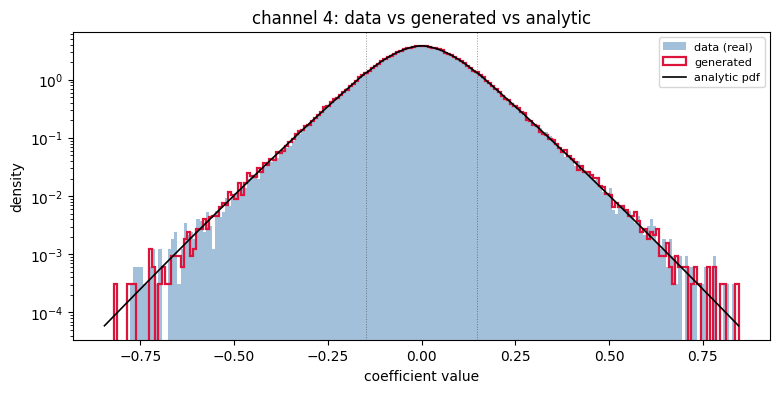

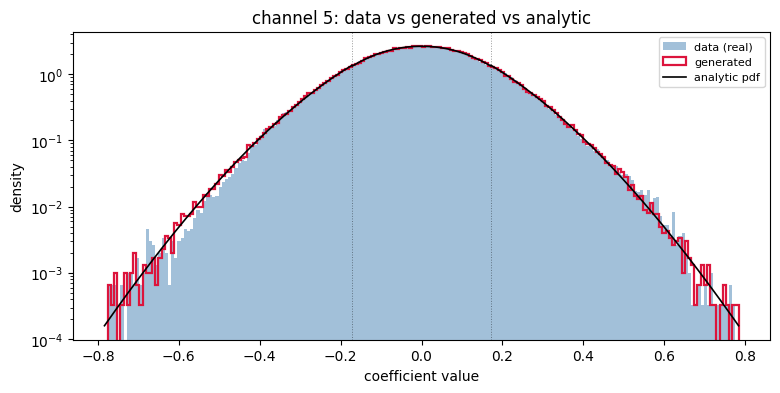

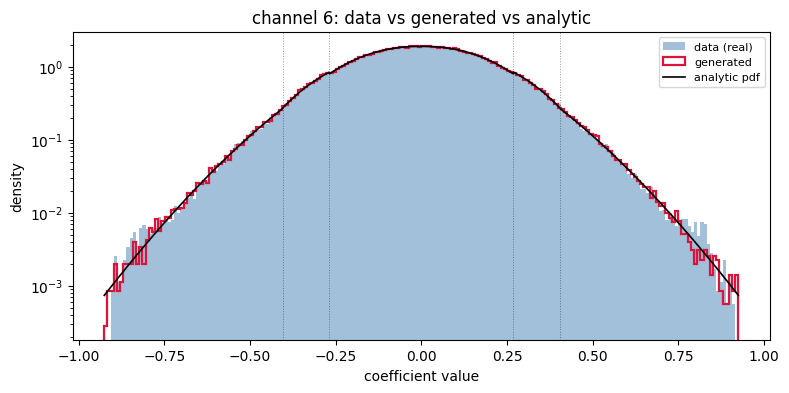

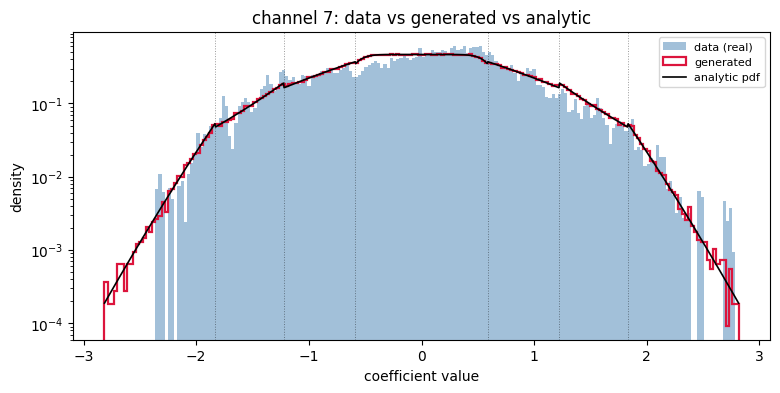

In [12]:
%matplotlib inline 
for i in range (0,filters.shape[1]): 
    model1.compare_channel(x1, j=i)

In [13]:
filtersQ = return_Filters(M, J, 3, device=device, include_phi=False)
print(filtersQ.shape)
model3 = Scalar_GGD_KRegion(filtersQ)
model3.fit_reference(x1)

torch.Size([1, 22, 128])
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-4027535  K2=-4064139  K3=-4068783  K4=-4069589)
[GGD^4][ch 0] Keff=4  cuts=[0.0005 0.0015 0.0062]  pi=[59.7% 21.4% 13.2% 5.7%]  alpha=[1.40 0.36 0.36 0.38]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-3852025  K2=-3868739  K3=-3871998  K4=-3872672)
[GGD^4][ch 1] Keff=4  cuts=[0.0002 0.0008 0.0083]  pi=[38.7% 25.6% 30.1% 5.6%]  alpha=[1.52 0.33 0.34 0.39]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-3276841  K2=-3281218  K3=-3282998  K4=-3283318)
[GGD^4][ch 2] Keff=4  cuts=[0.0002 0.0019 0.0309]  pi=[18.5% 45.7% 33.6% 2.2%]  alpha=[1.56 0.29 0.35 0.42]  active=4
    [model-select] chose K=2  (Kmax=4)  (BIC: K1=-2741834  K2=-2743711  K3=-2743582  K4=-2743697)
[GGD^4][ch 3] Keff=2  cuts=[0.0000 0.0000 0.0004]  pi=[0.0% 0.0% 18.5% 81.5%]  alpha=[1.00 2.38 1.19 0.31]  active=2
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-2299768  K2=-2300975  K3=-2300918  K4=-2301028)
[GGD^4][ch 4] 

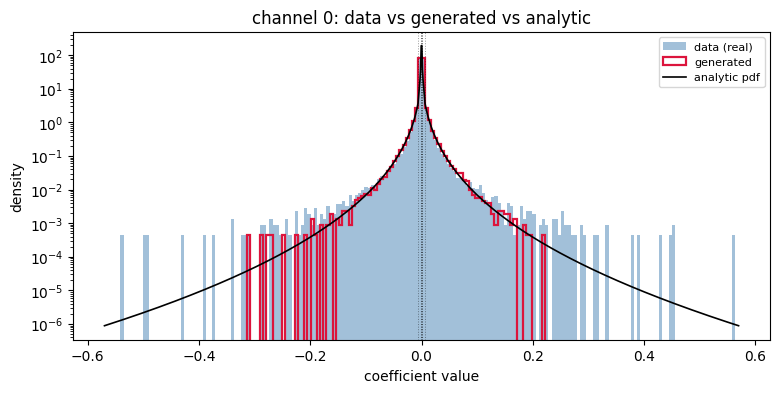

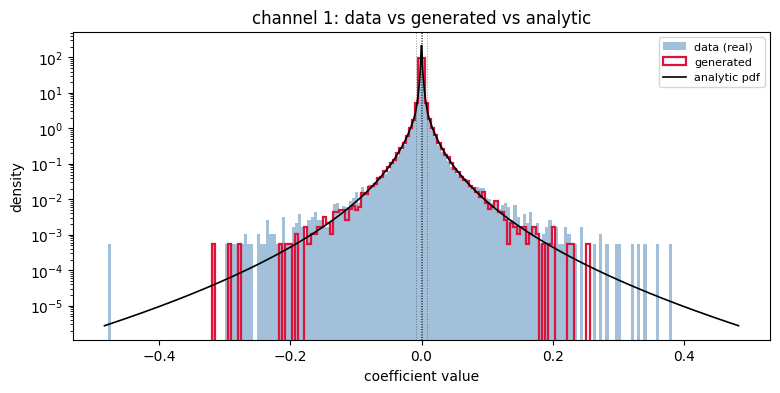

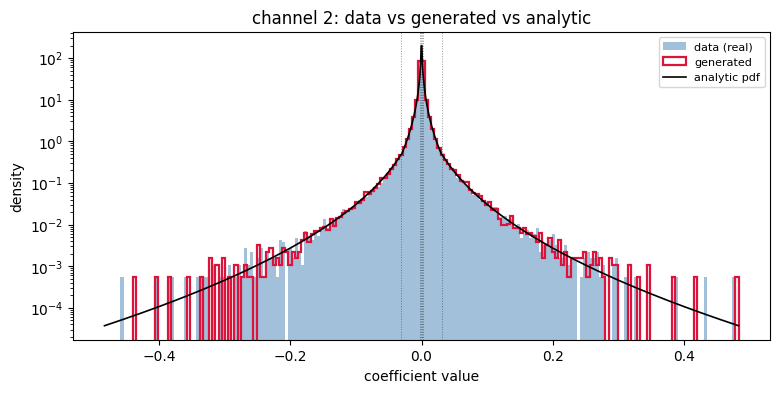

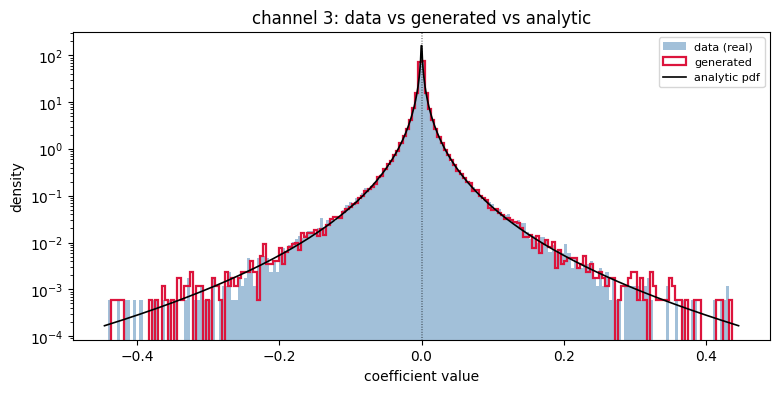

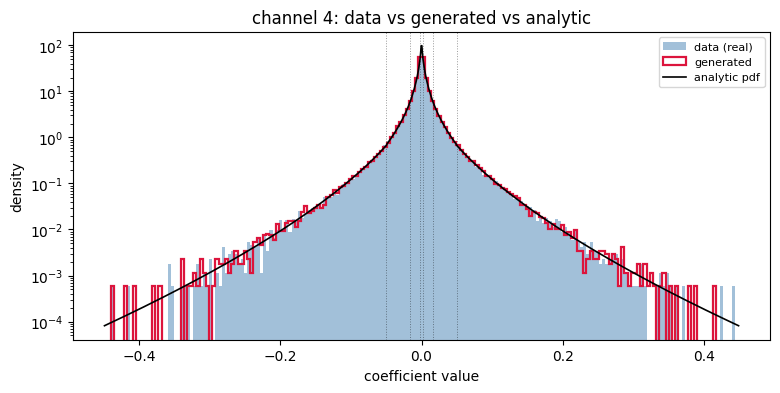

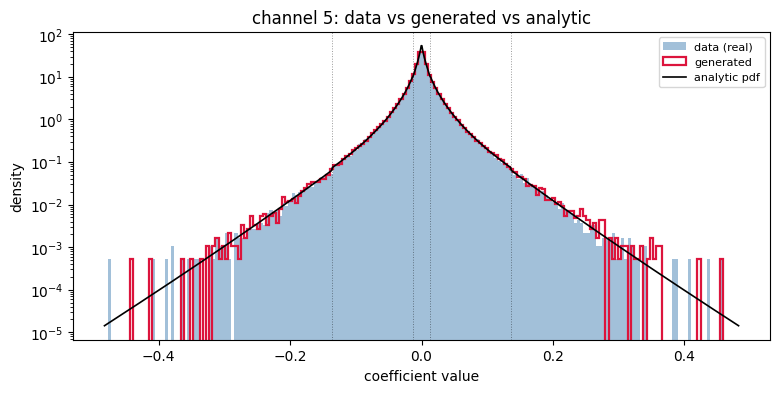

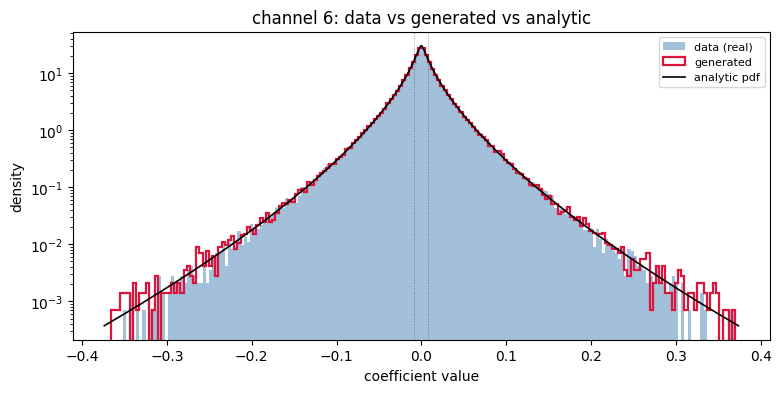

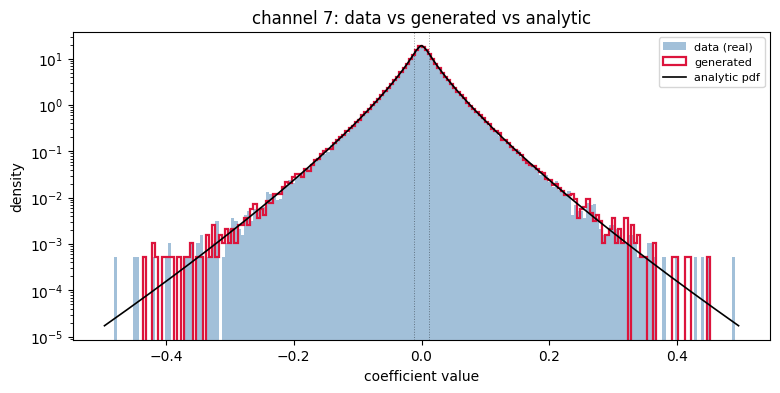

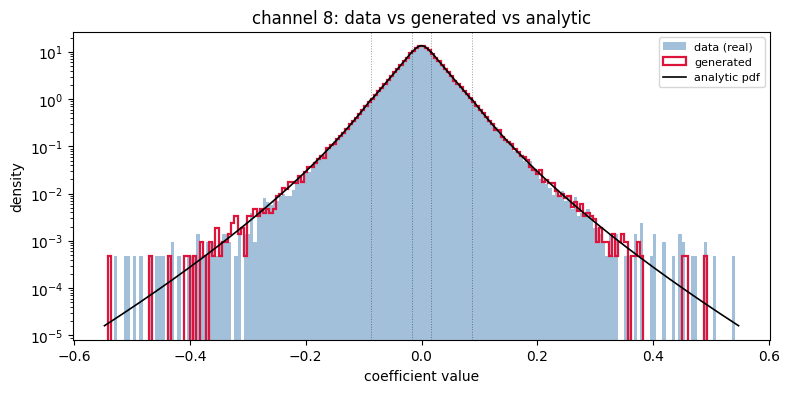

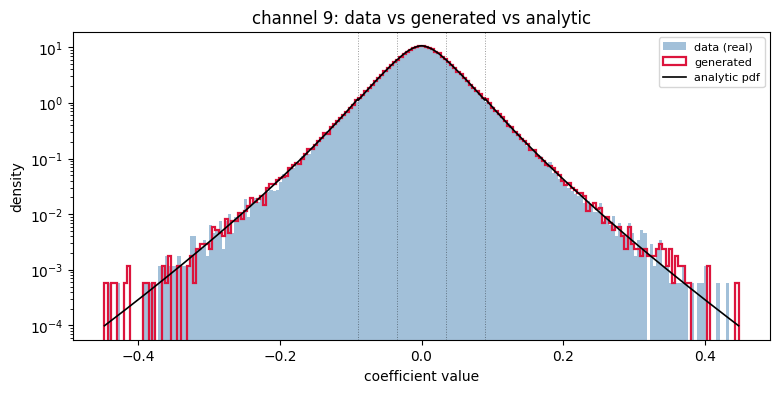

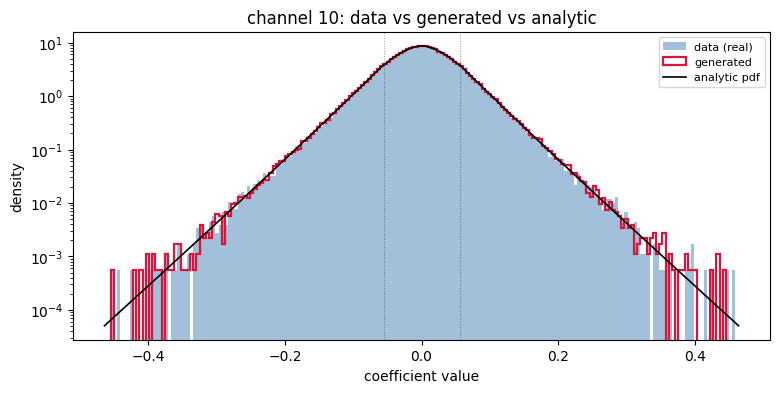

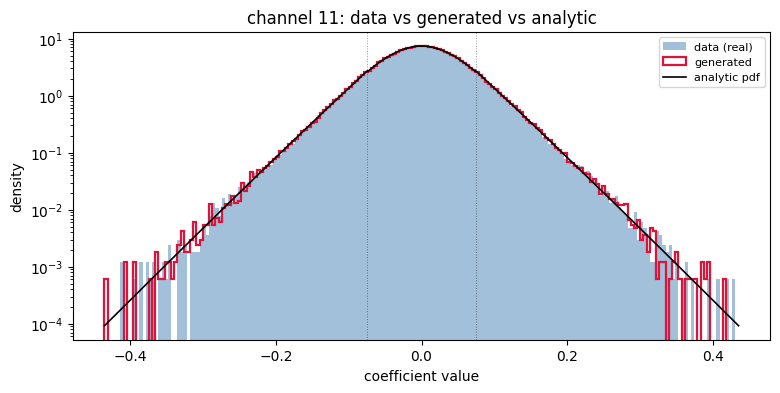

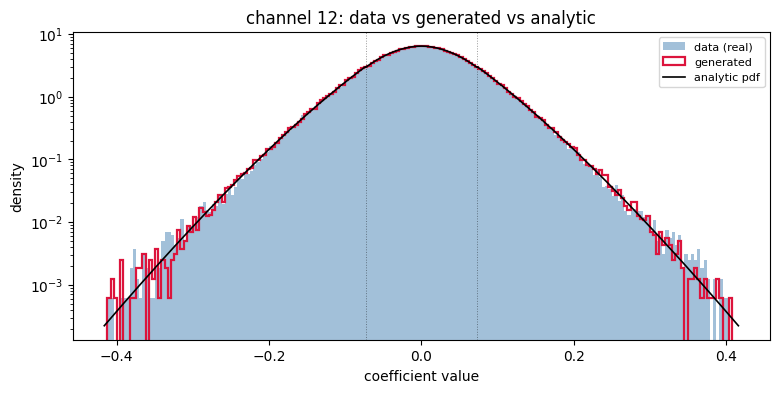

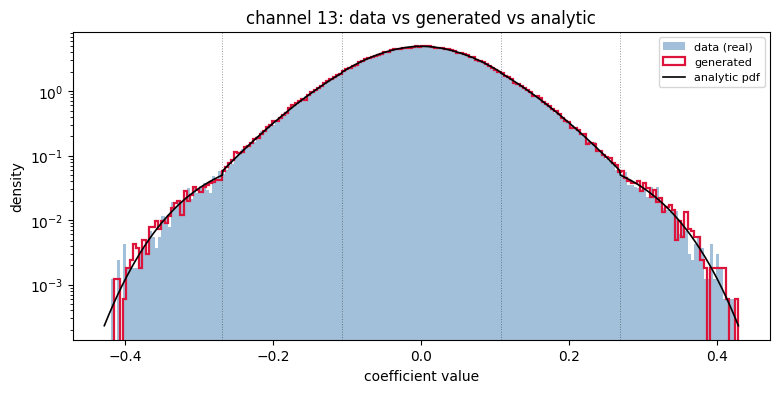

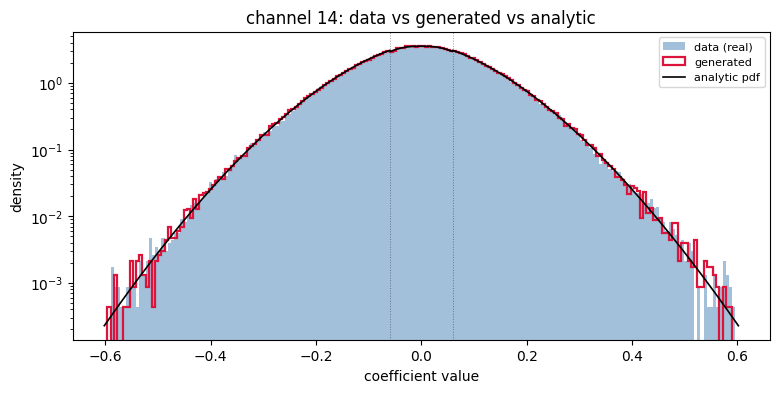

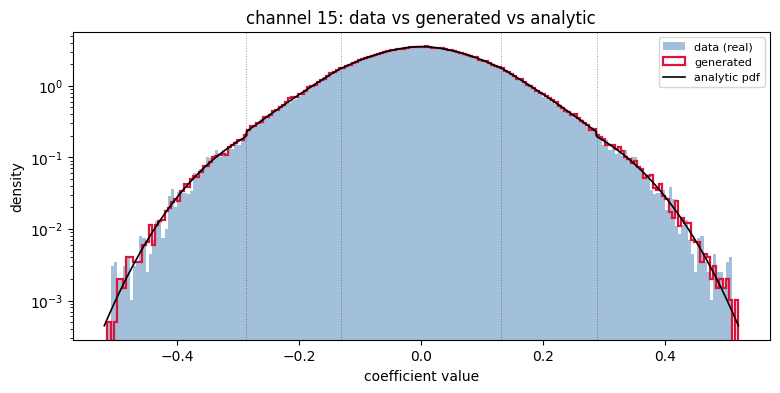

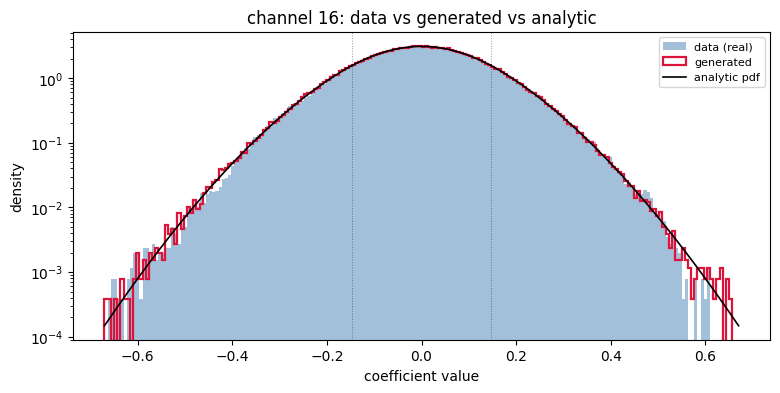

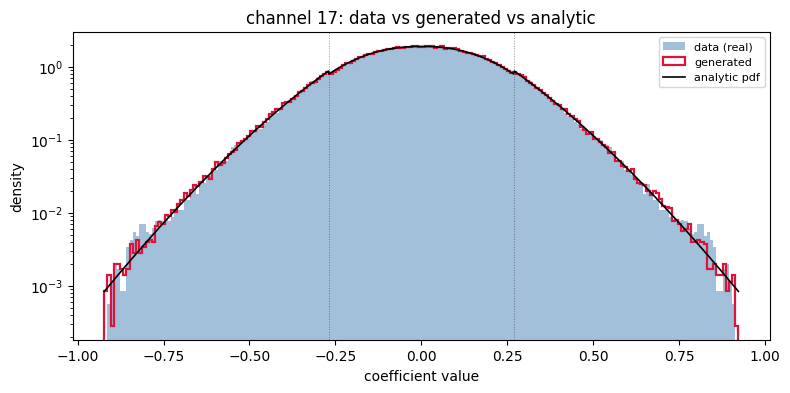

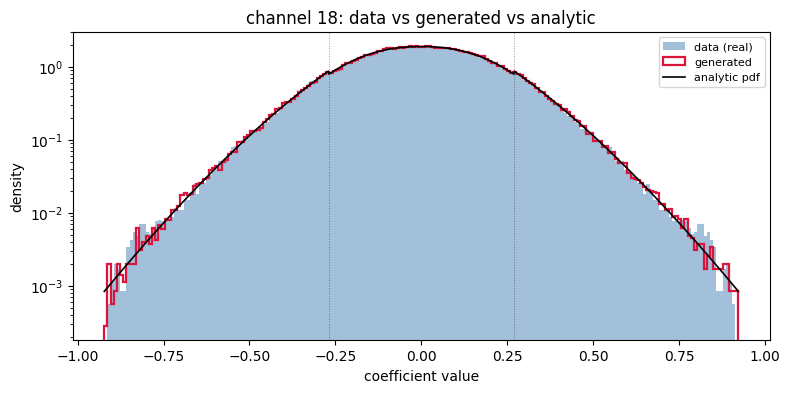

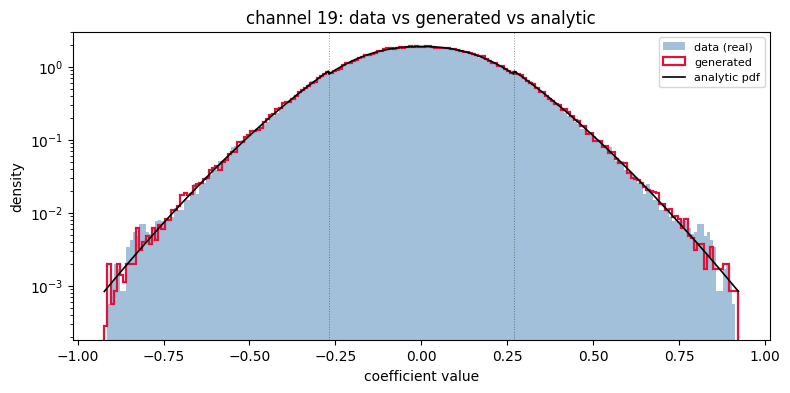

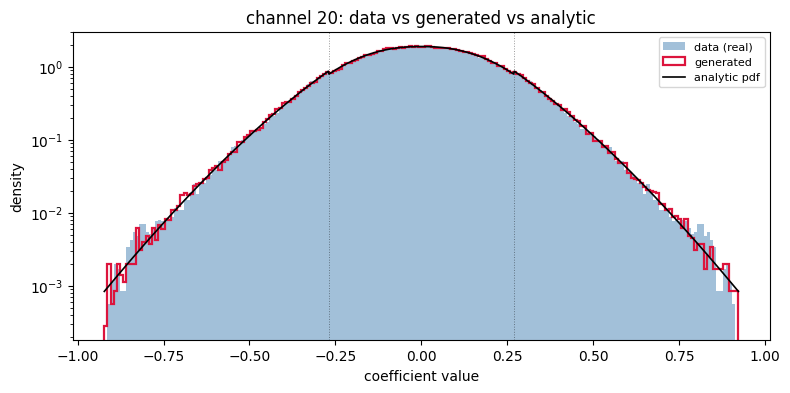

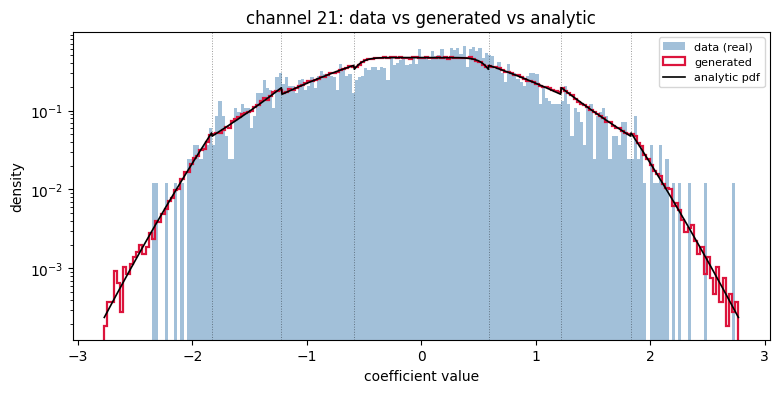

In [14]:
%matplotlib inline 
for i in range(0,filtersQ.shape[1]): 
    model3.compare_channel(x1, j=i)

## Analyze results 

In [16]:
theta_t = result['theta_t']
print(theta_t.shape, theta_t.device)
theta_reg_t = result['Theta_reg']

torch.Size([9704, 79]) cpu


In [17]:
theta_reg_t[:,5]

tensor([ -1066.8459,  -1149.1995,  -1169.1860,  -1290.6187,  -1297.2622,
         -1495.4169,  -1554.5208,  -1836.7517,  -2139.8342,  -2279.9131,
         -2778.8379,  -3065.9241,  -3459.4072,  -3907.7917,  -4676.0986,
         -5732.5171,  -6464.0332,  -7657.2812,  -8957.4844, -10440.7295,
        -11203.6152, -14164.7207, -15879.7490, -16238.9521, -18519.5039,
        -18056.3945, -15291.1162, -11859.5264,  -9724.9336,  -4349.1626,
         -1283.1305,    386.1680,   3480.5723,   1603.9437,    306.5648,
           841.3906,   -607.6682,    214.1825,    228.5769,    -23.4341,
          -127.9269,   1307.8978,    123.4397,   -160.8964,     55.4282,
           638.7132,    881.7881,   -909.4479,  -1015.2292,   -853.2921,
          -652.0341,    -22.6622,    367.2745,    -56.6361,   -635.0521,
          1434.0184,    516.2892,   -716.9091,   -184.2923,   1324.9113,
           574.8489,   2047.9558,    477.1986])

## Coarse grain 

9704 63


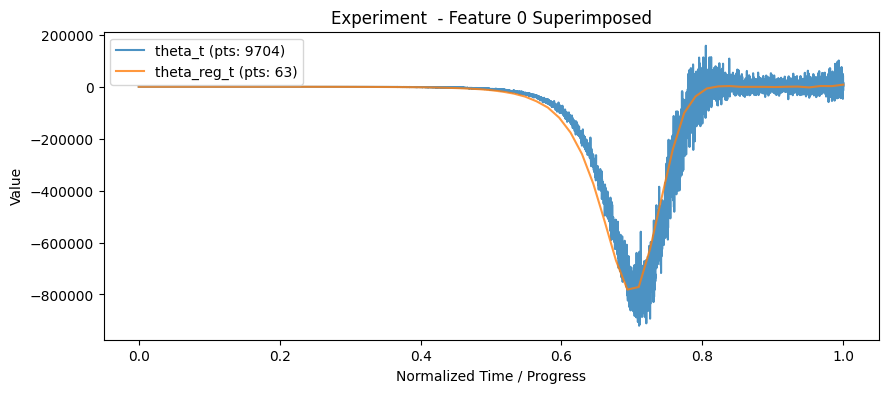

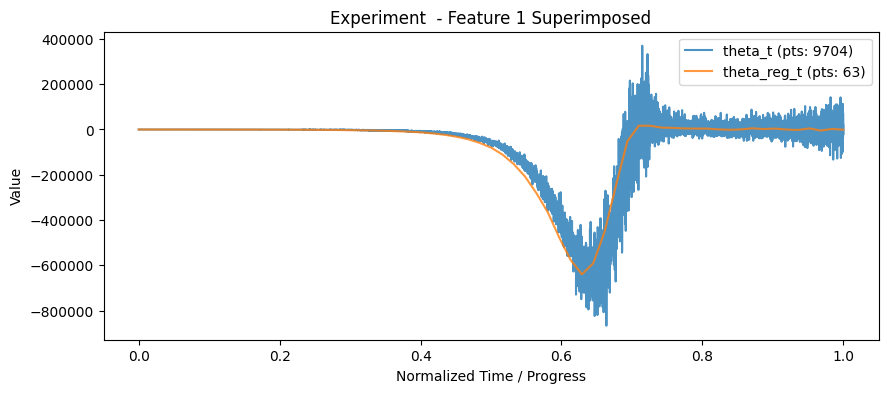

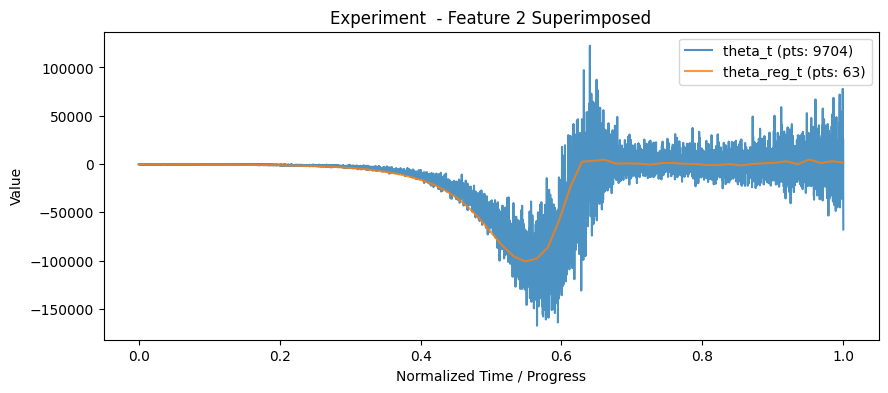

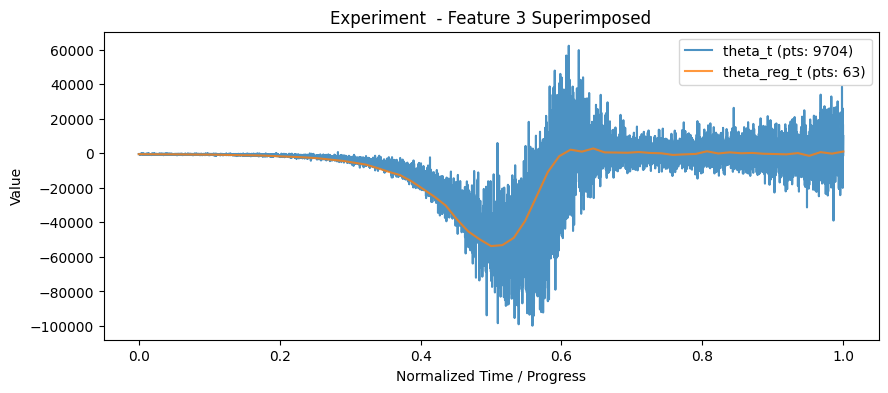

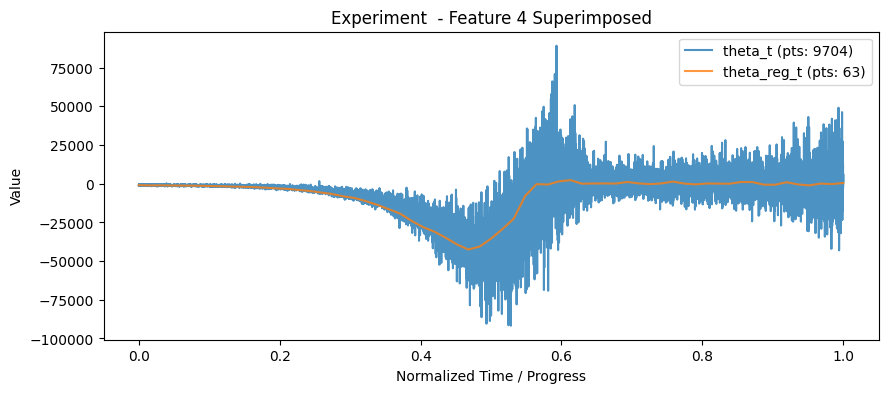

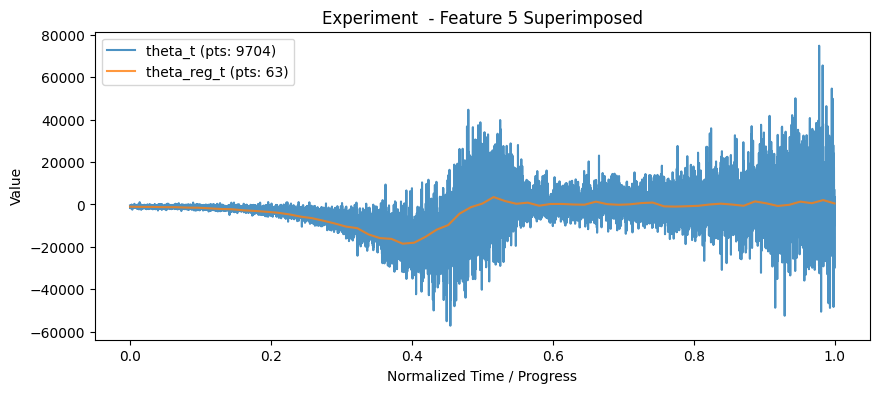

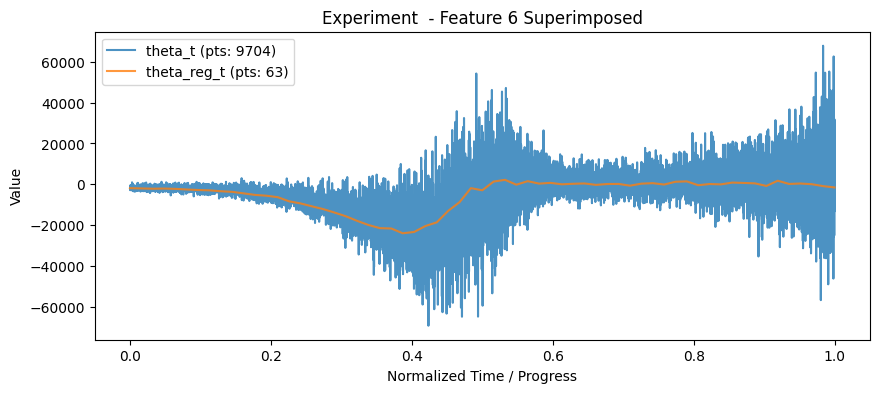

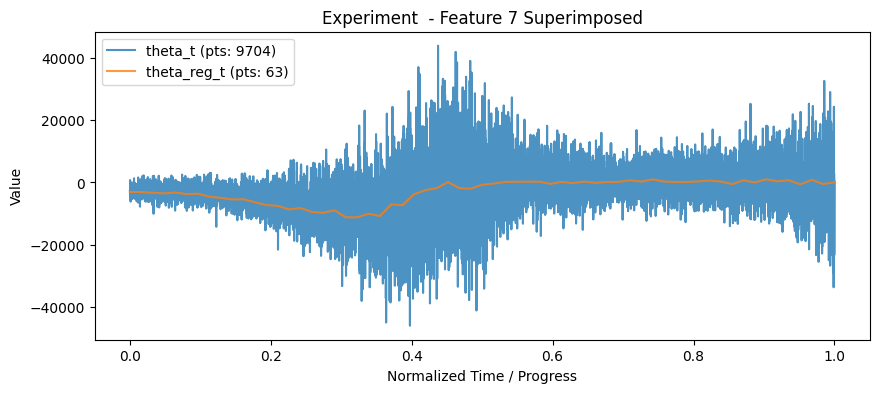

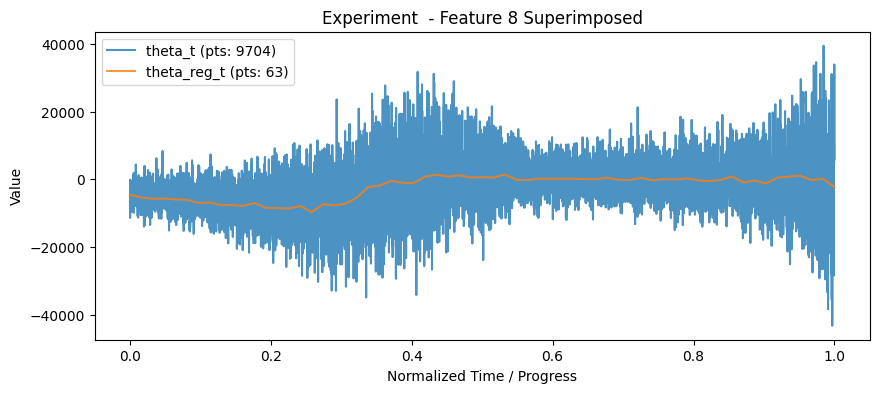

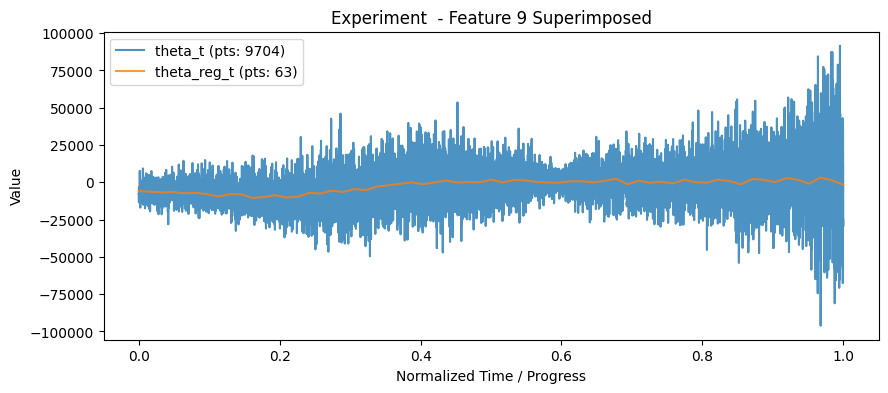

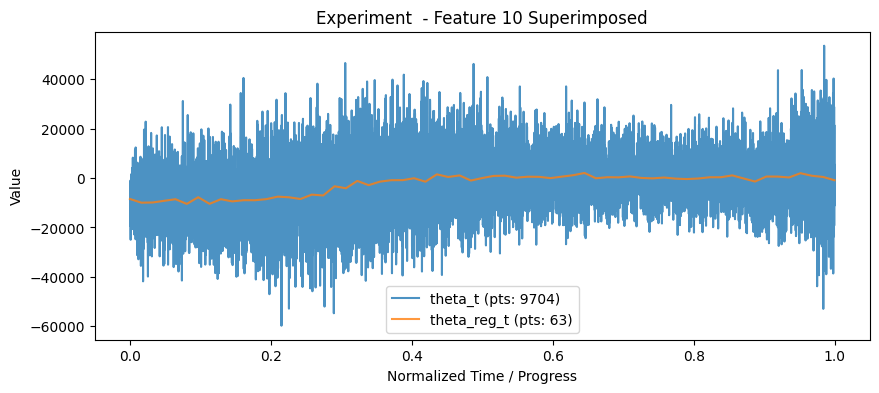

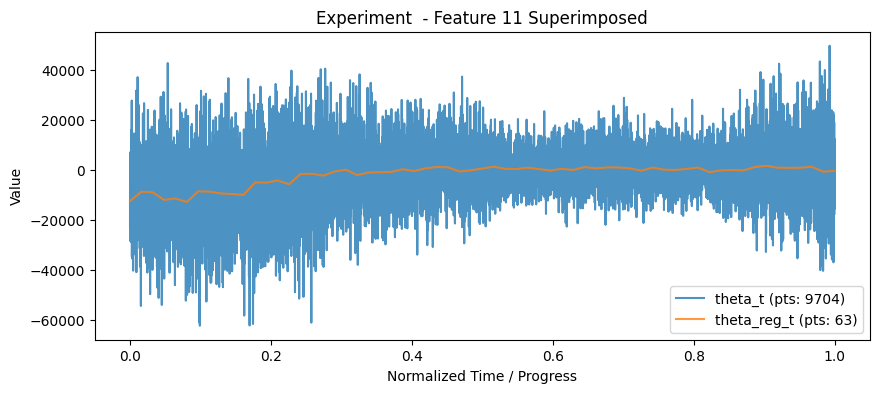

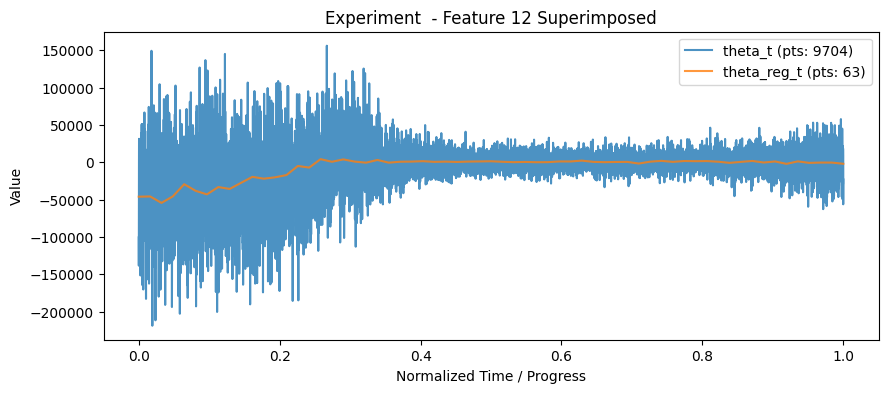

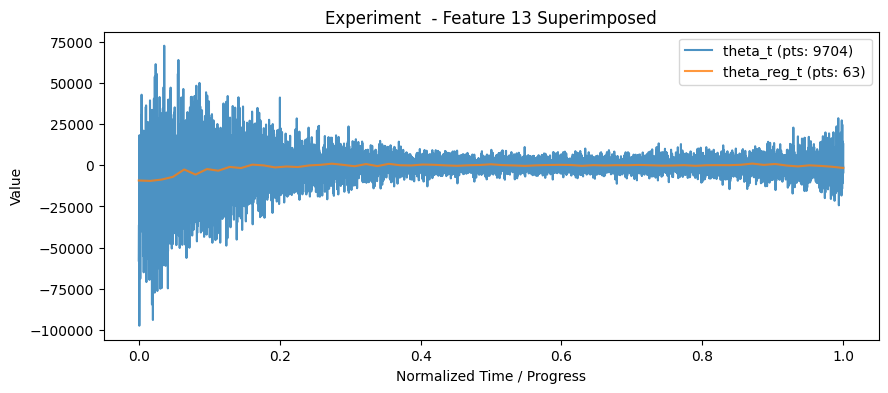

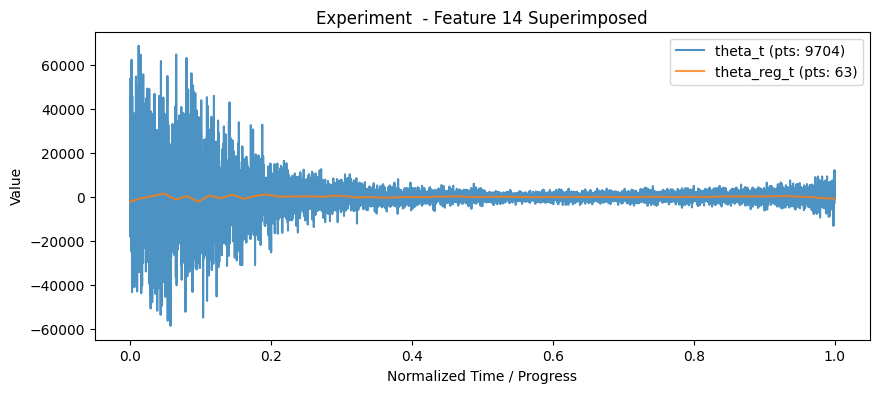

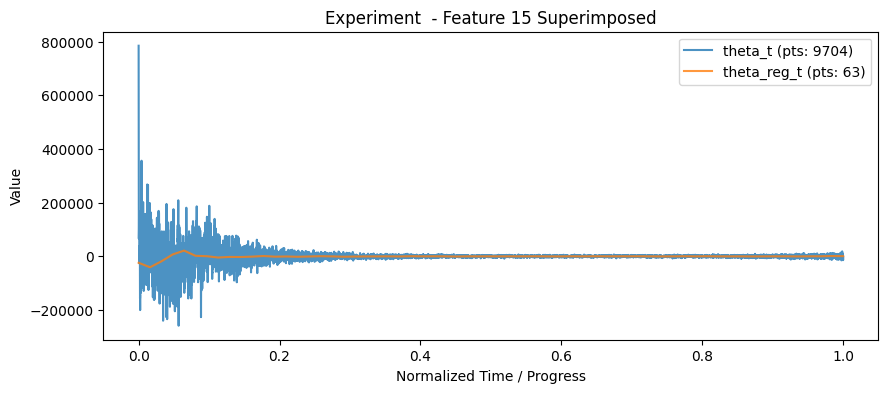

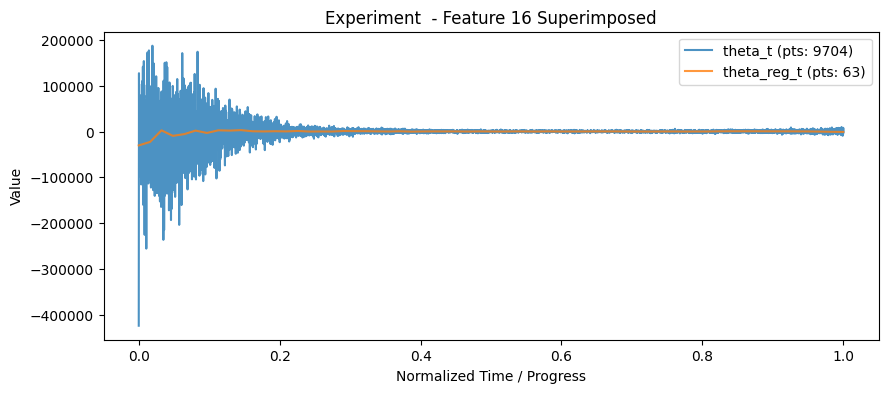

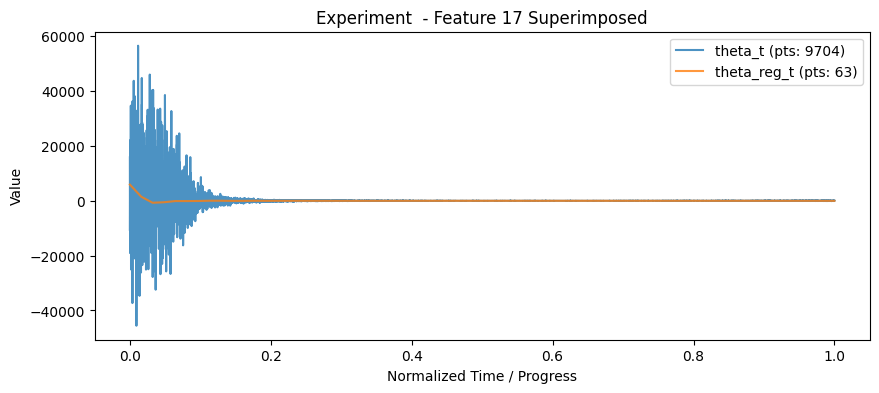

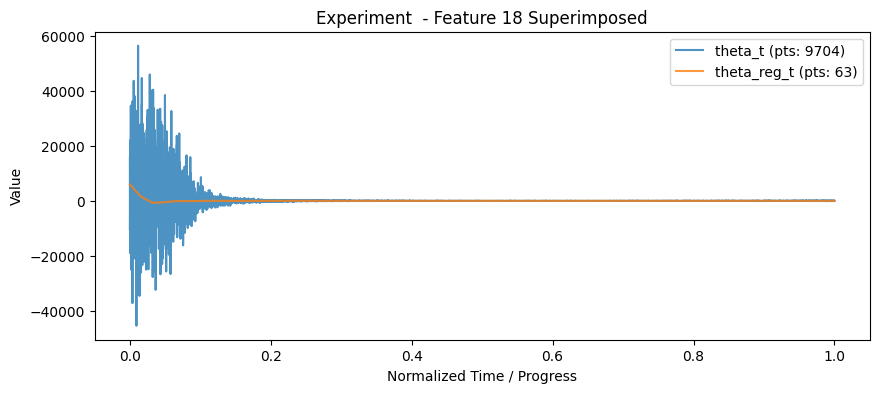

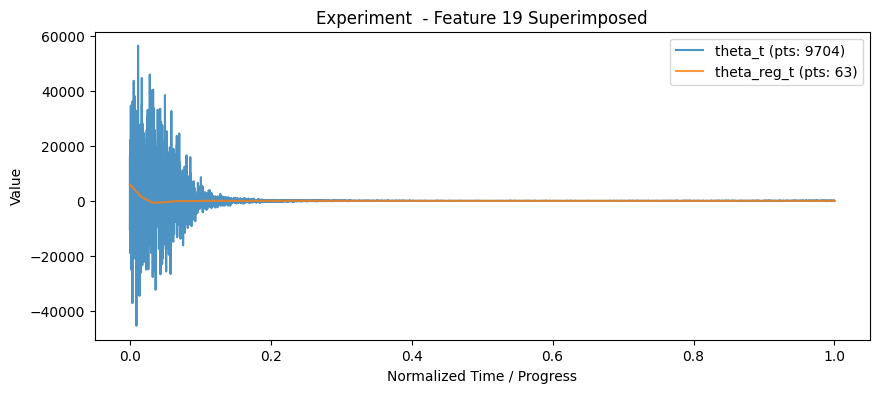

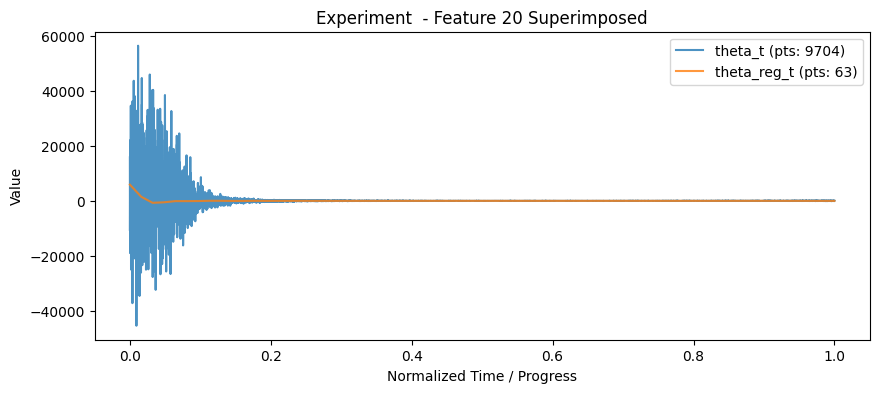

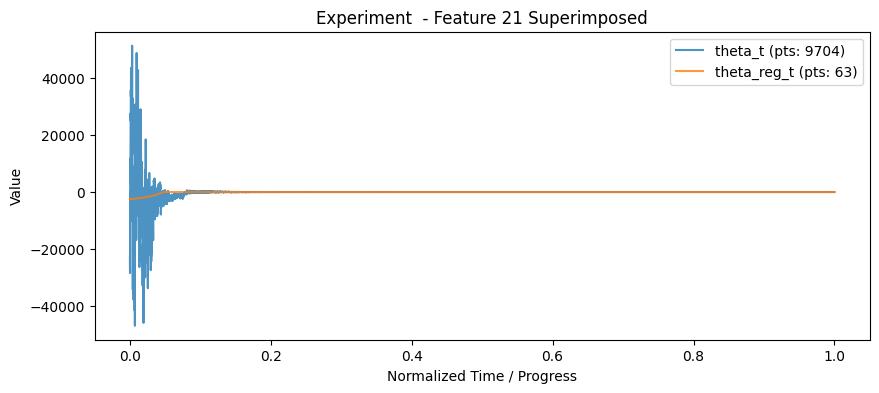

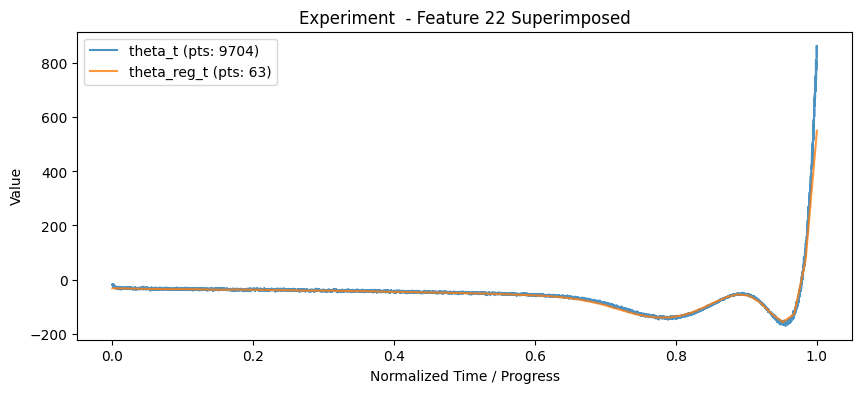

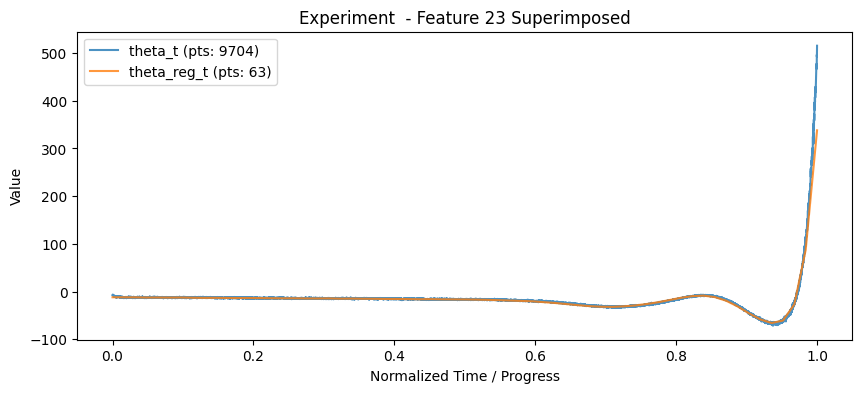

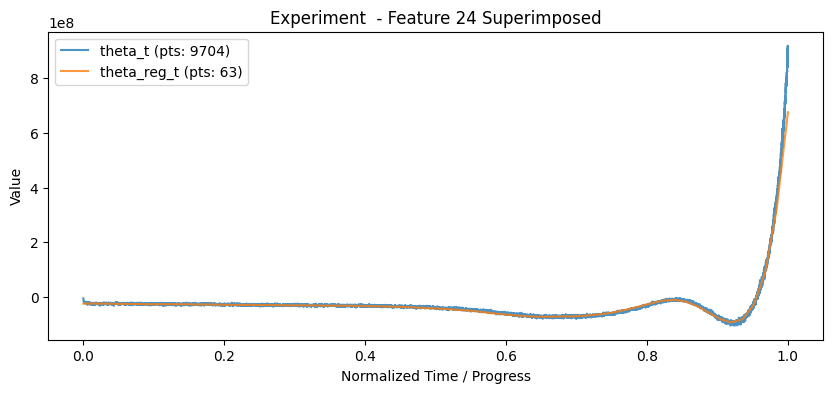

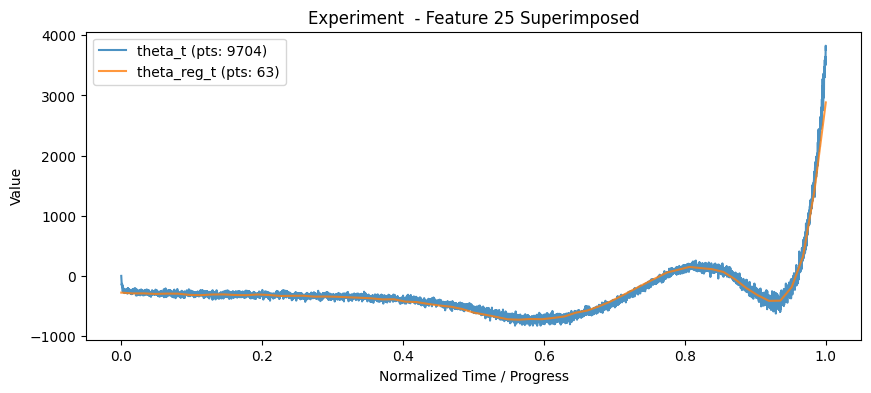

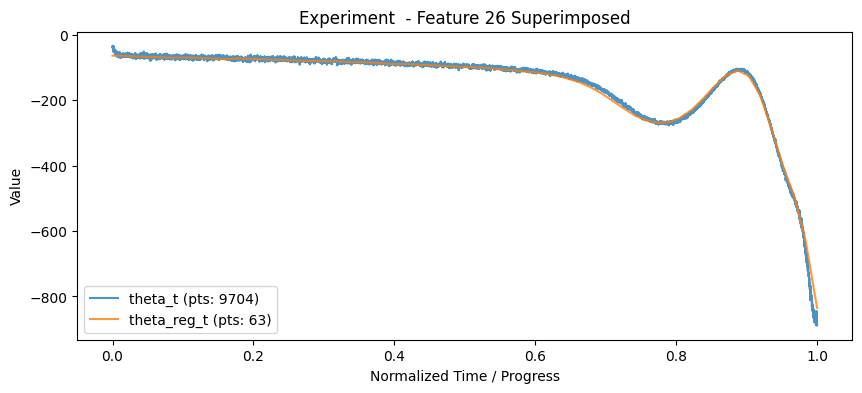

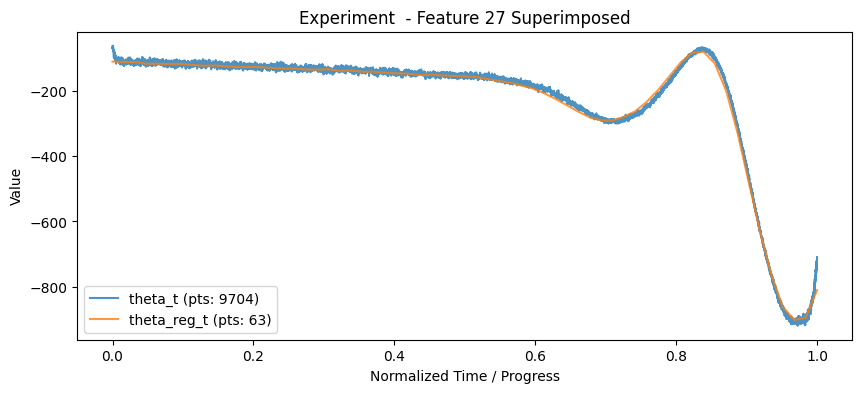

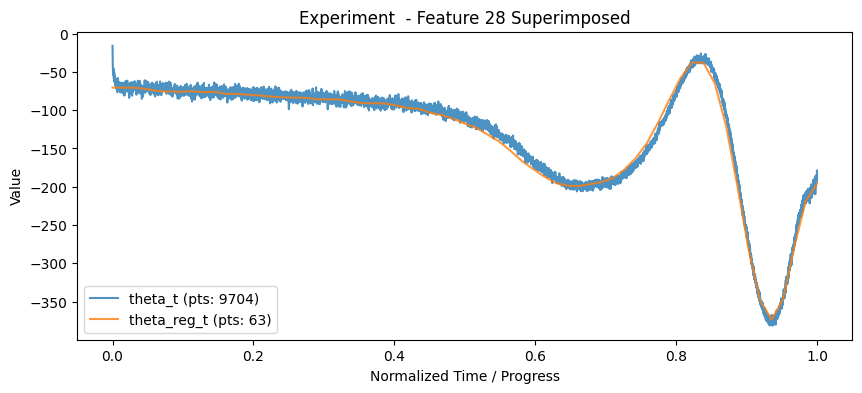

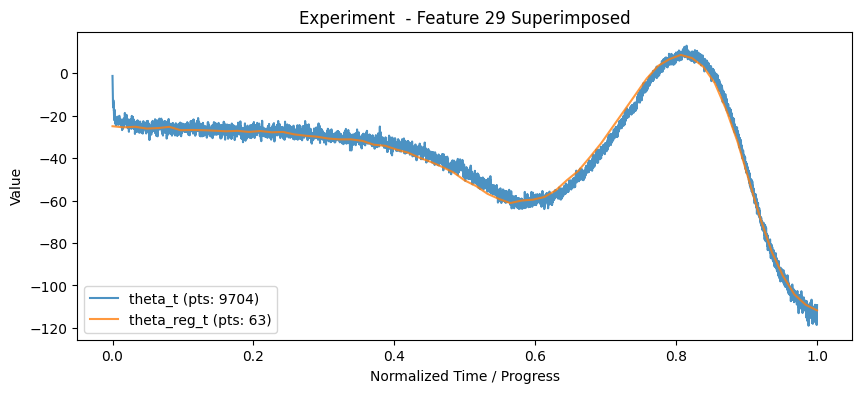

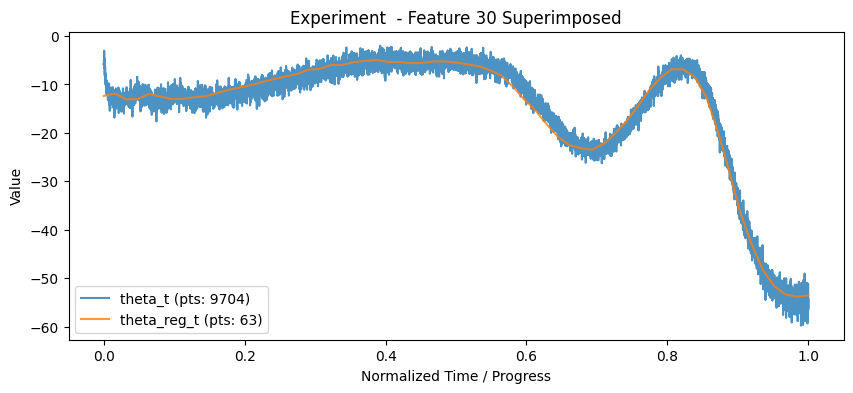

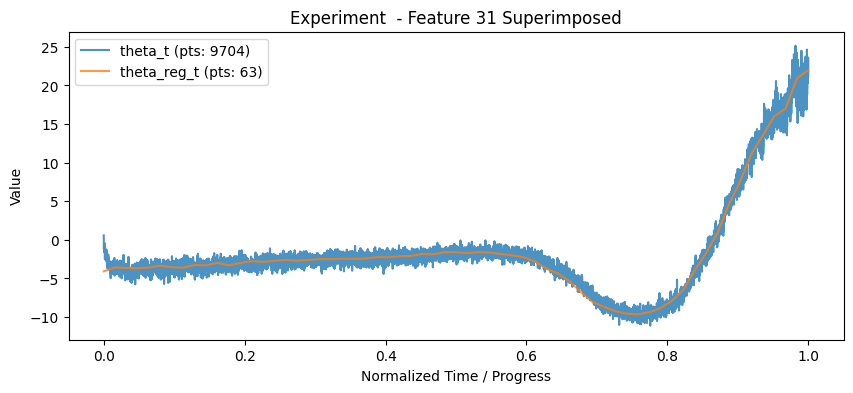

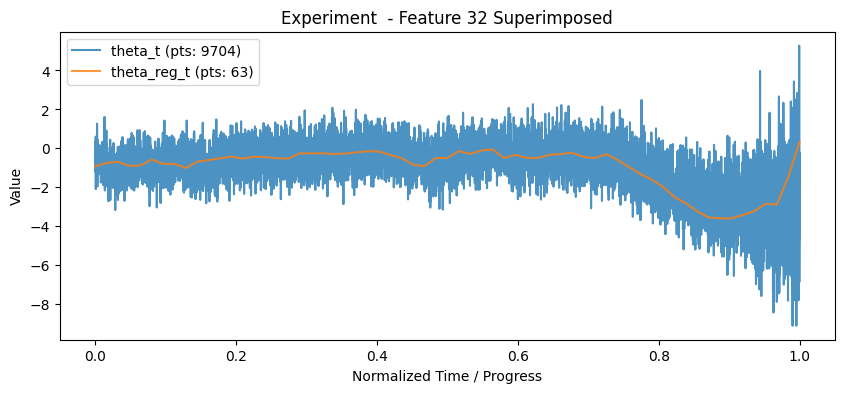

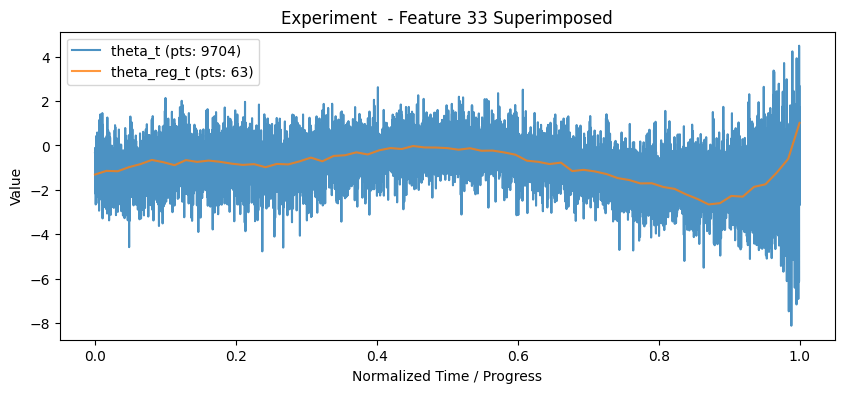

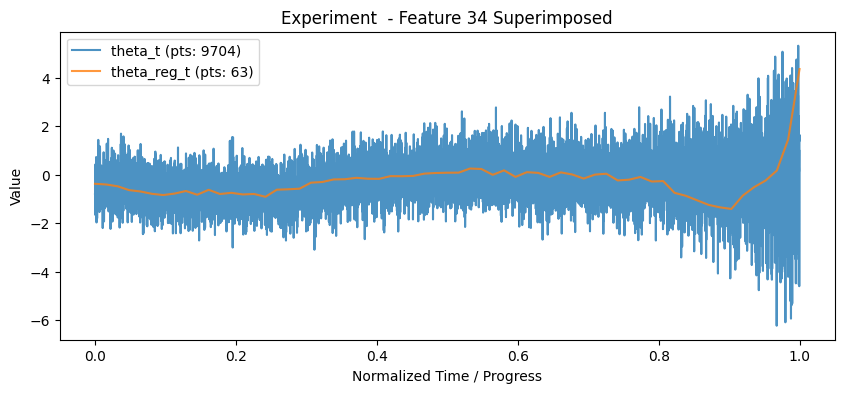

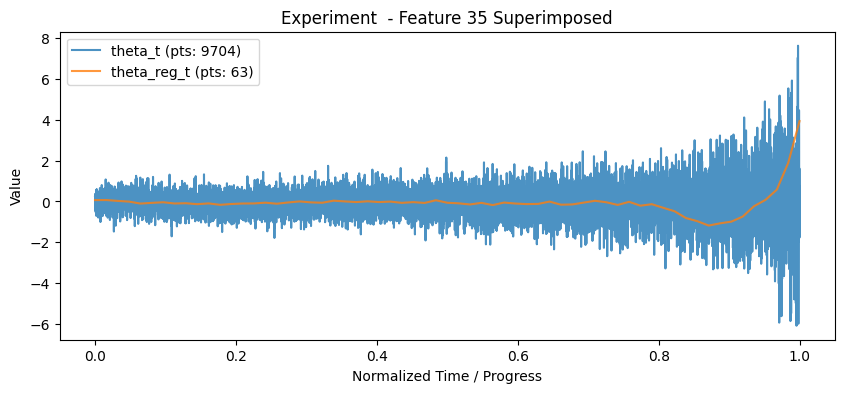

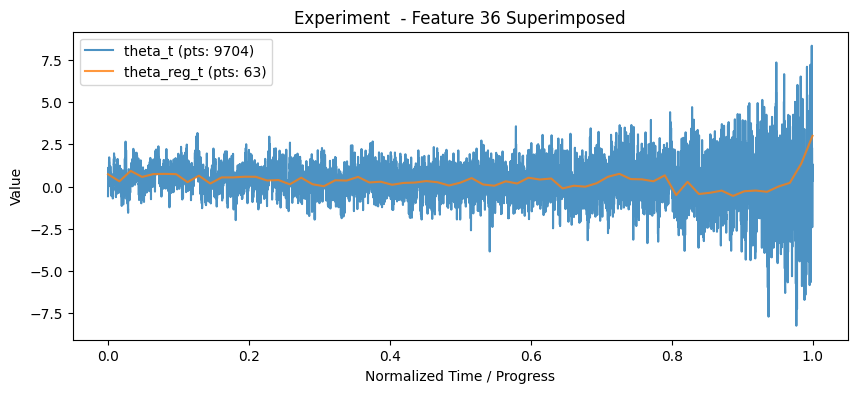

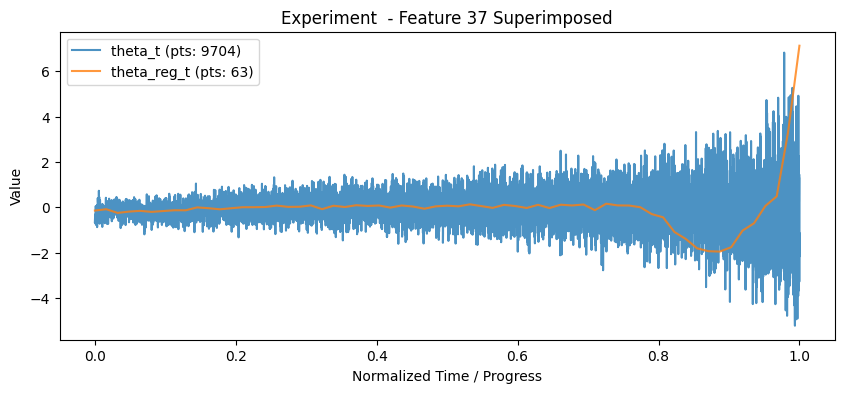

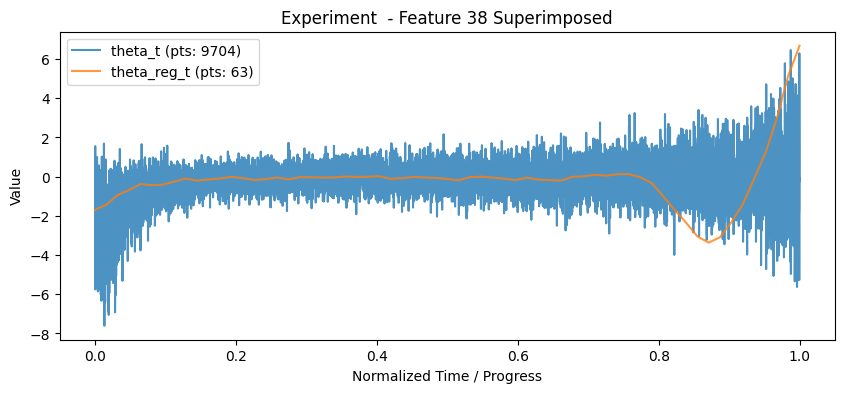

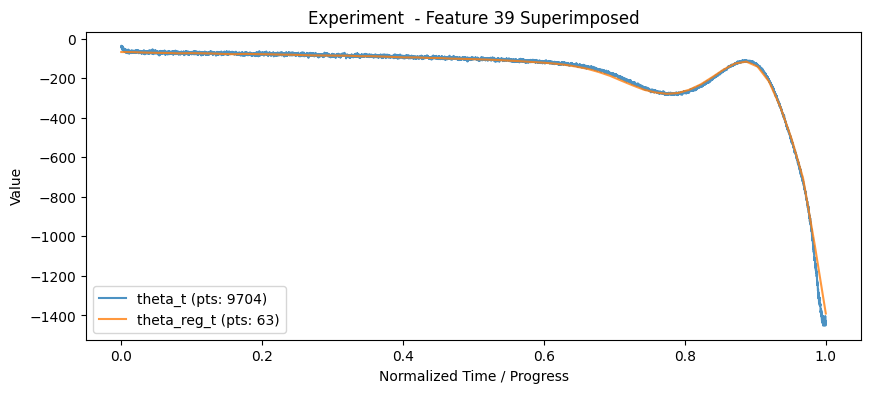

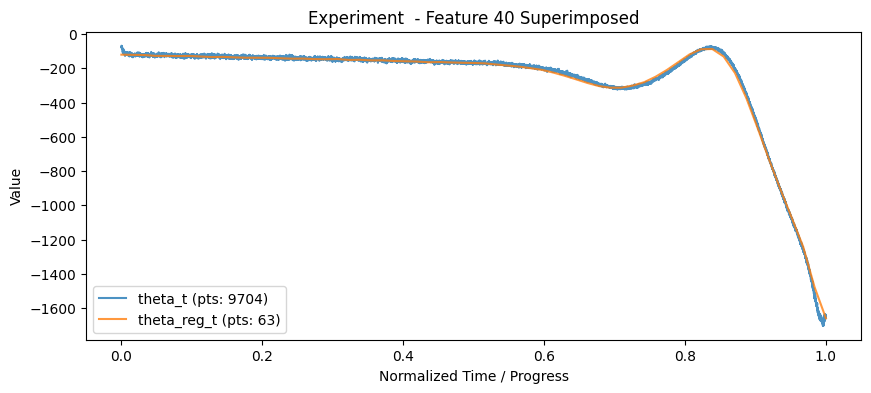

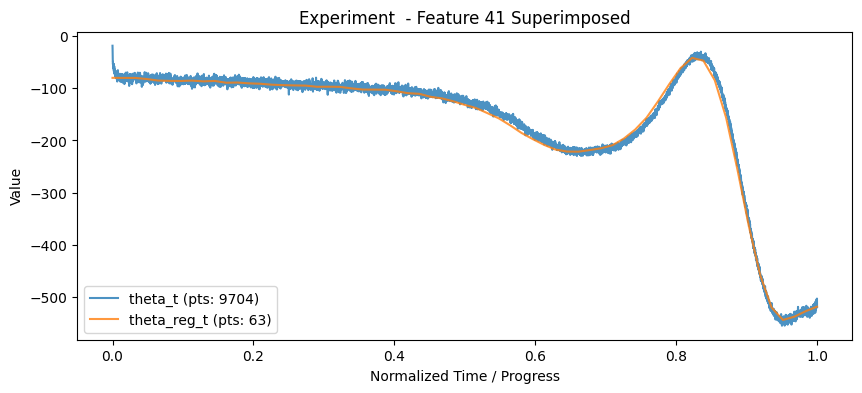

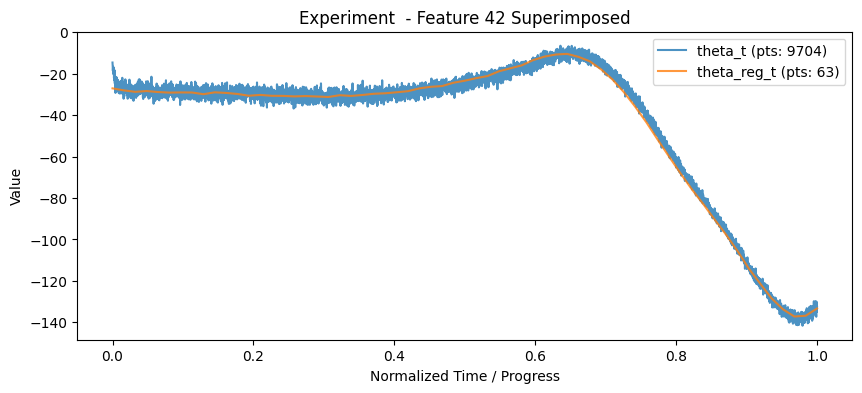

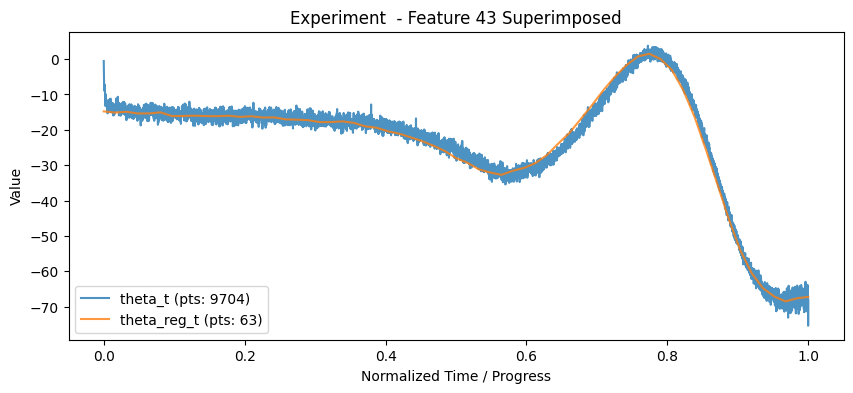

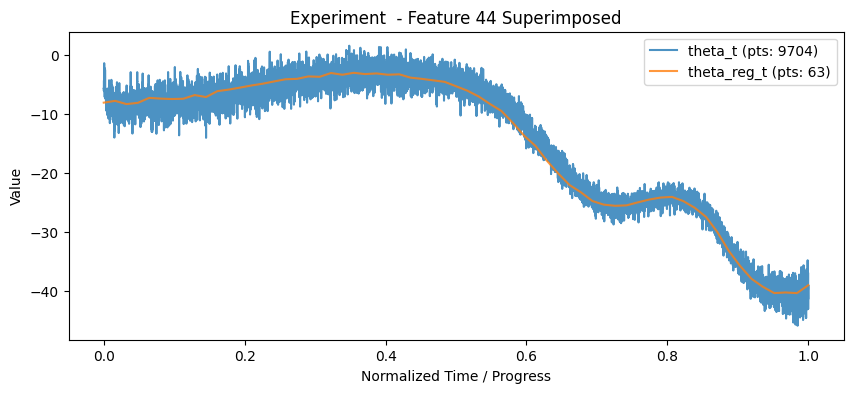

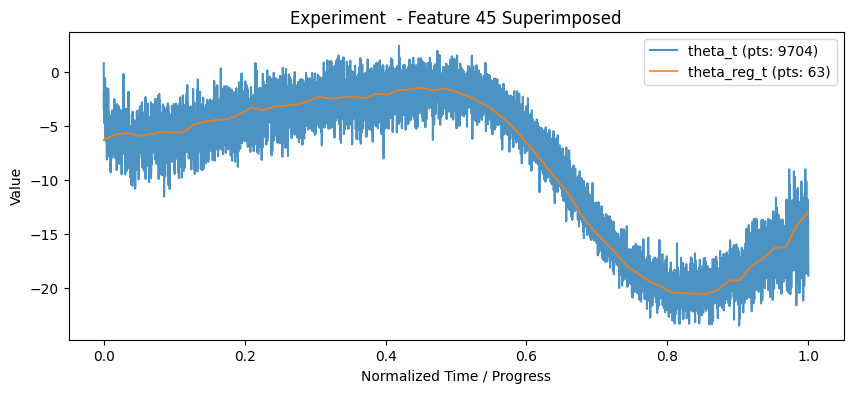

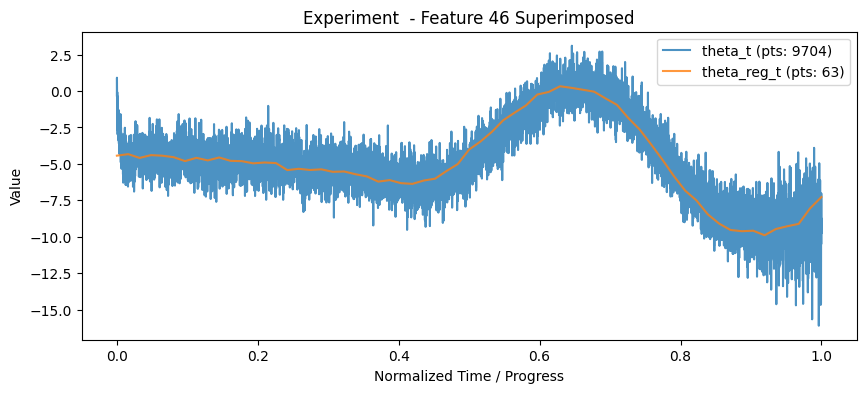

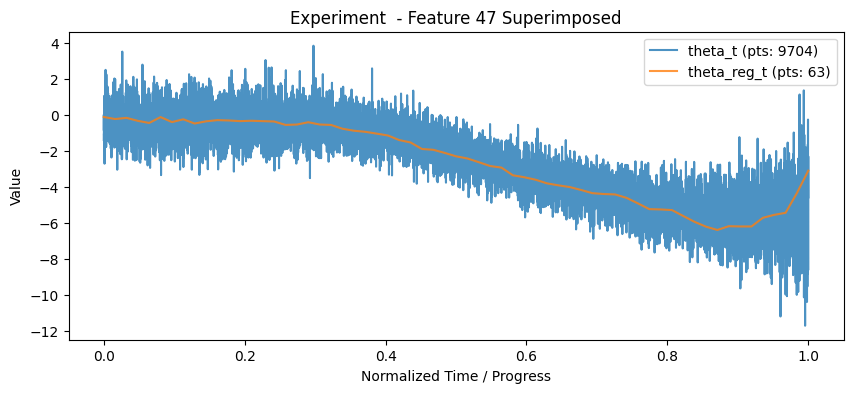

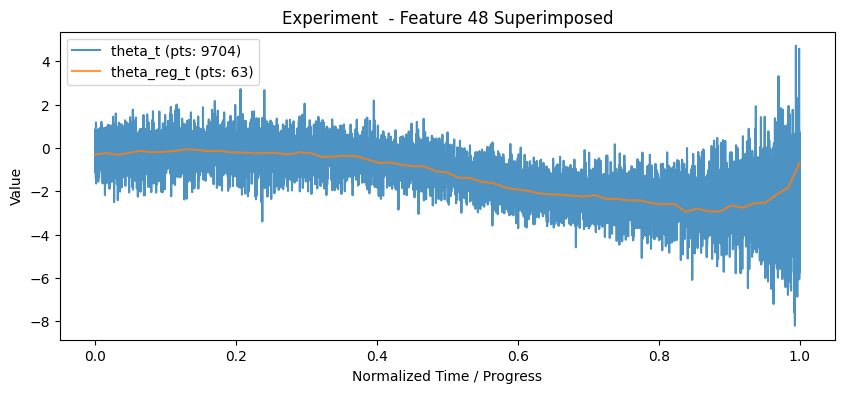

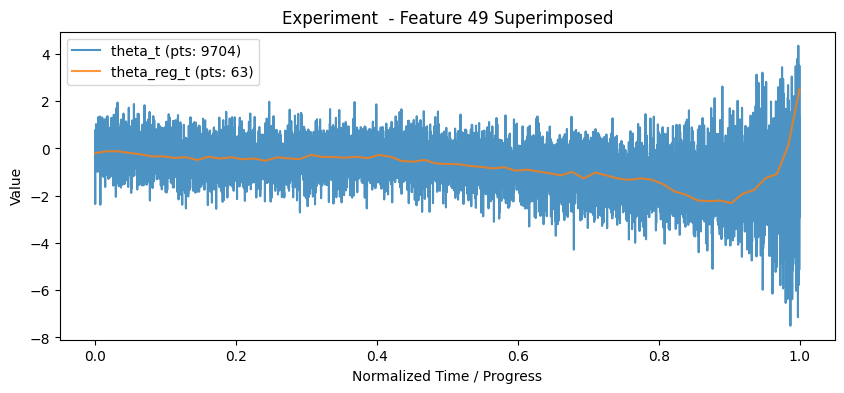

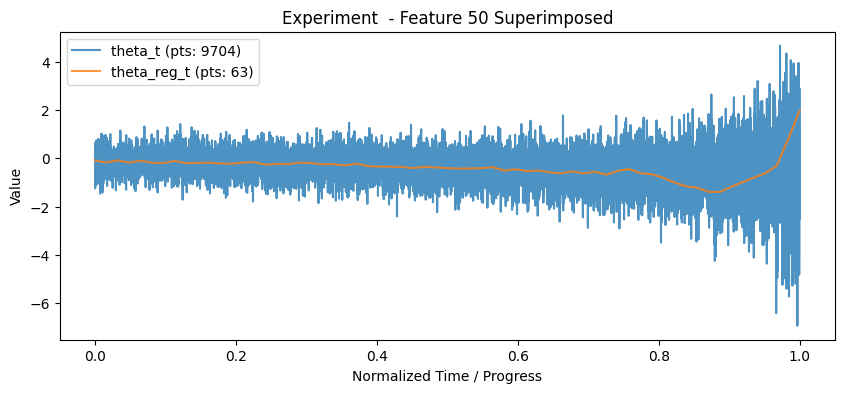

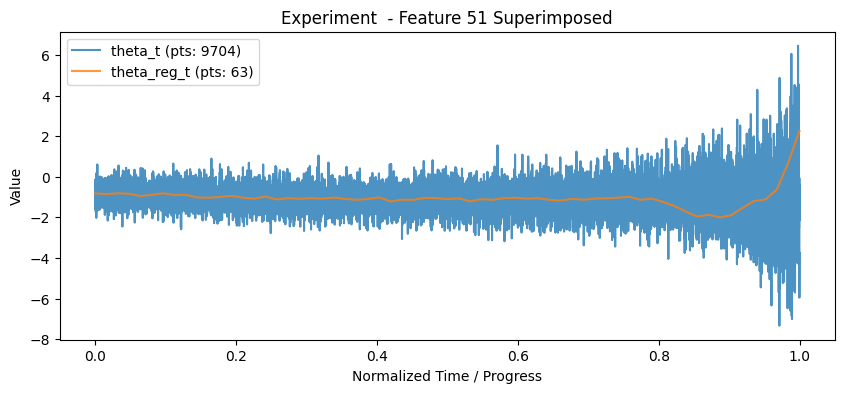

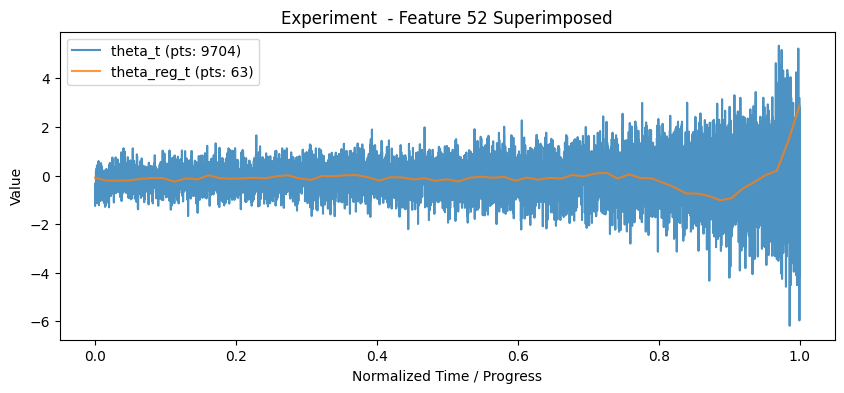

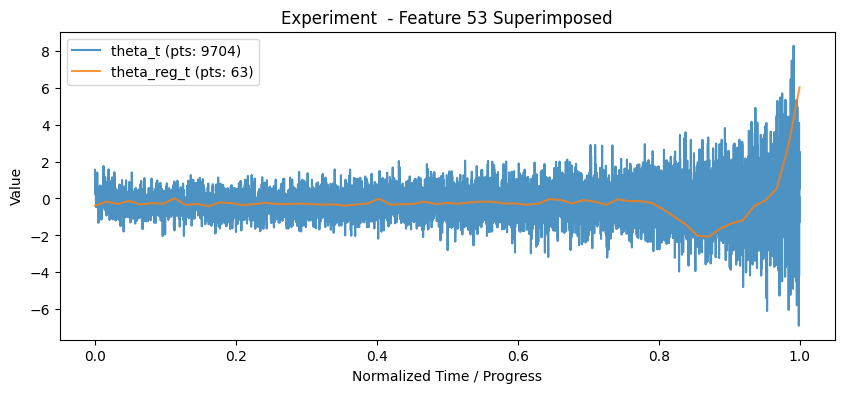

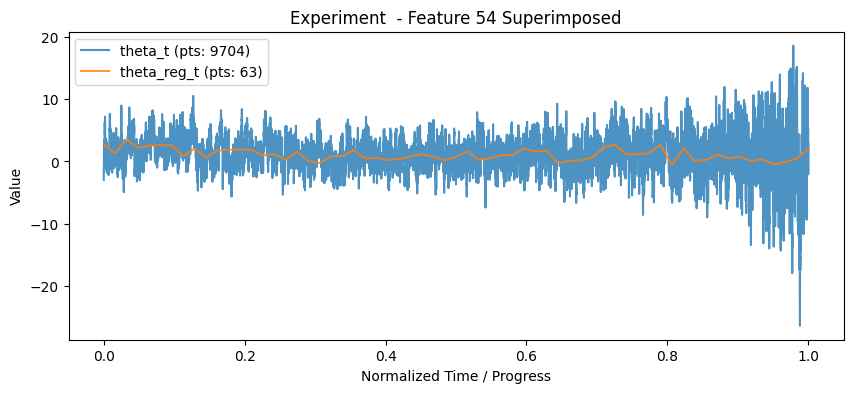

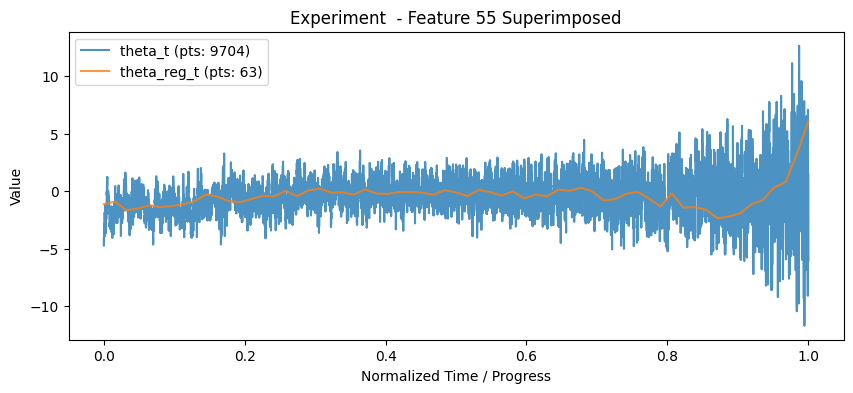

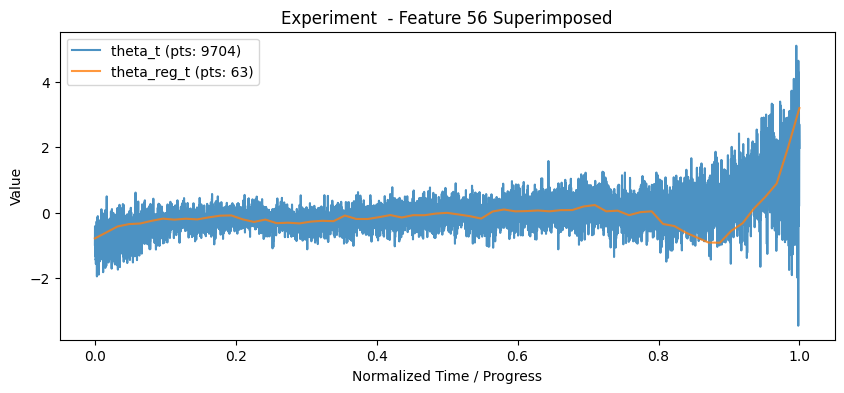

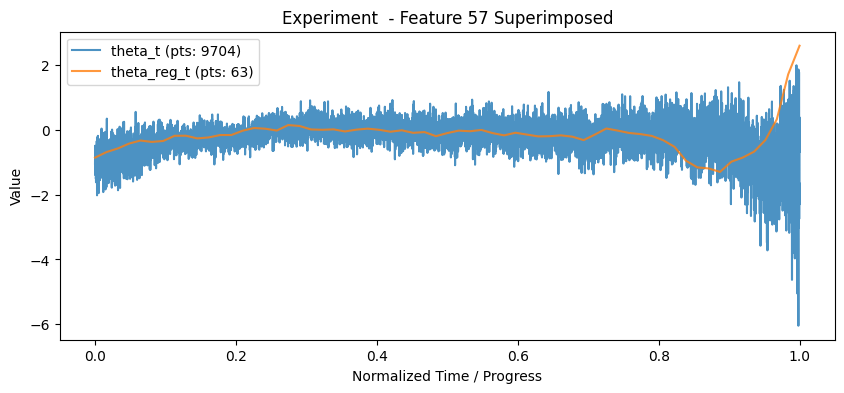

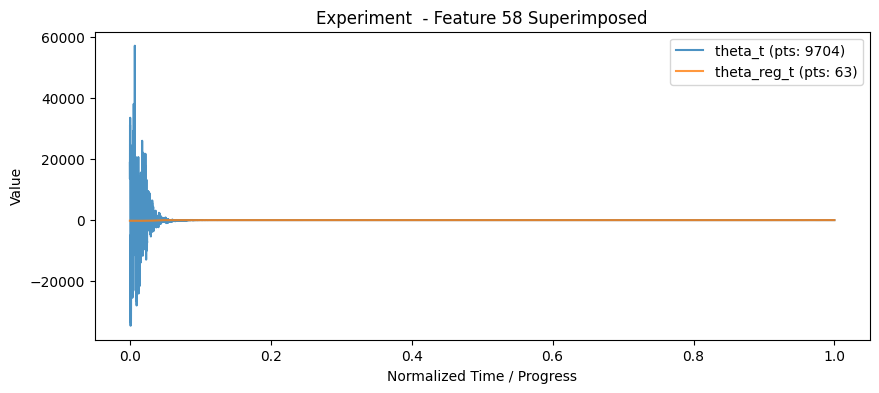

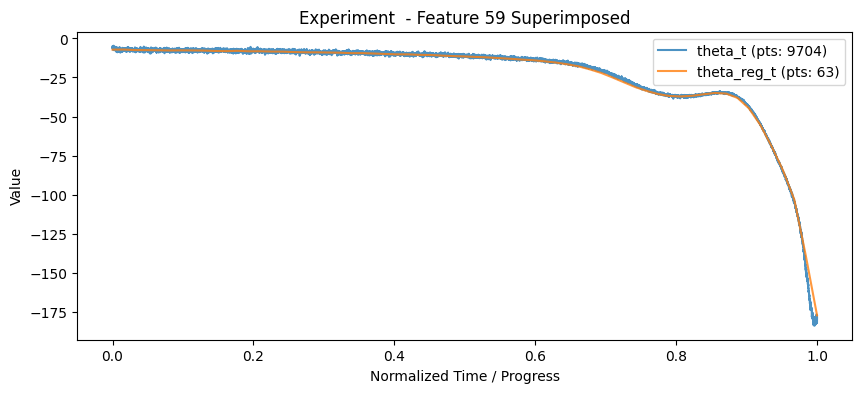

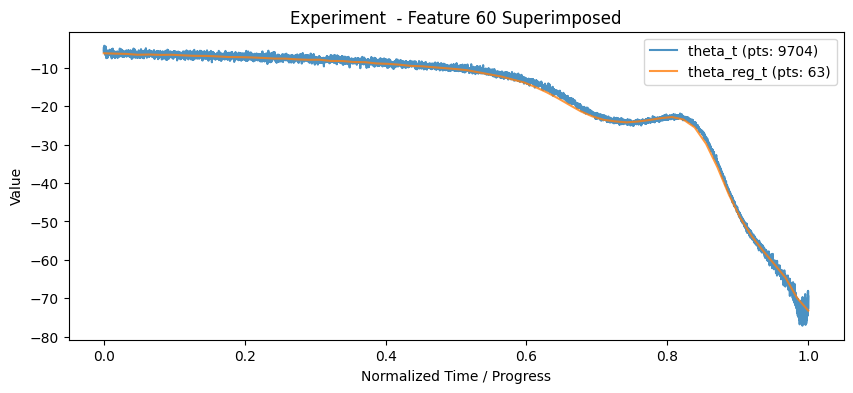

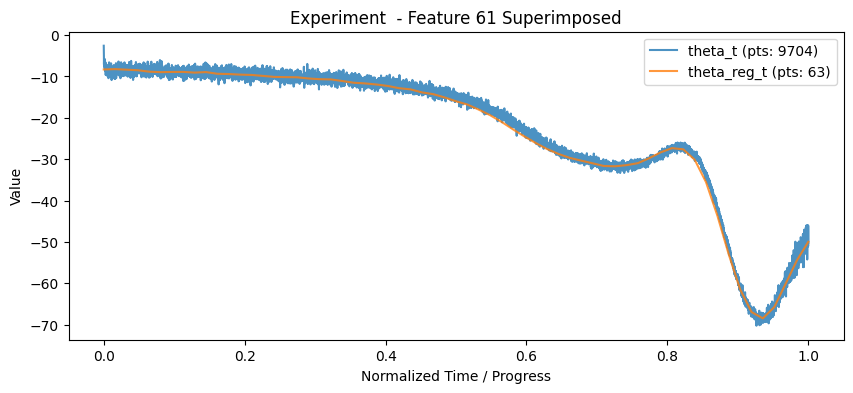

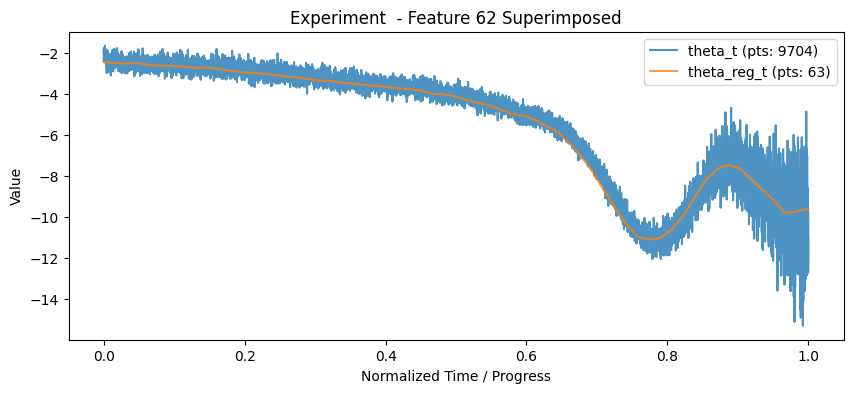

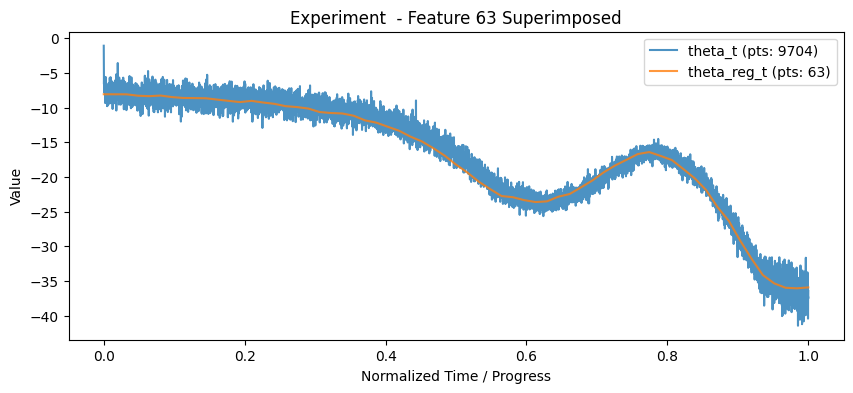

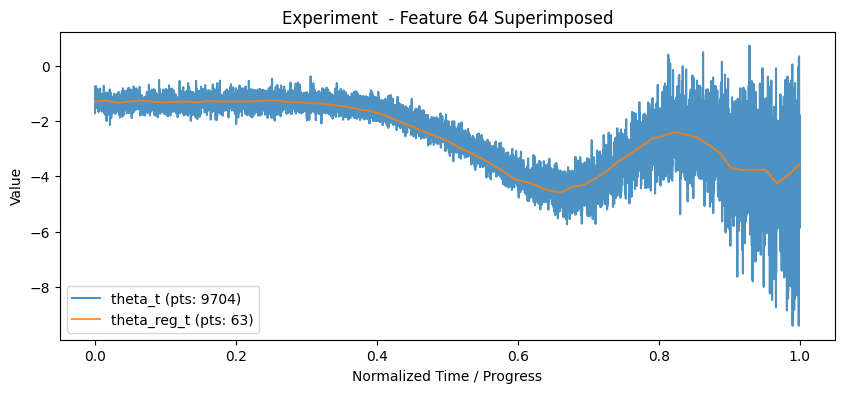

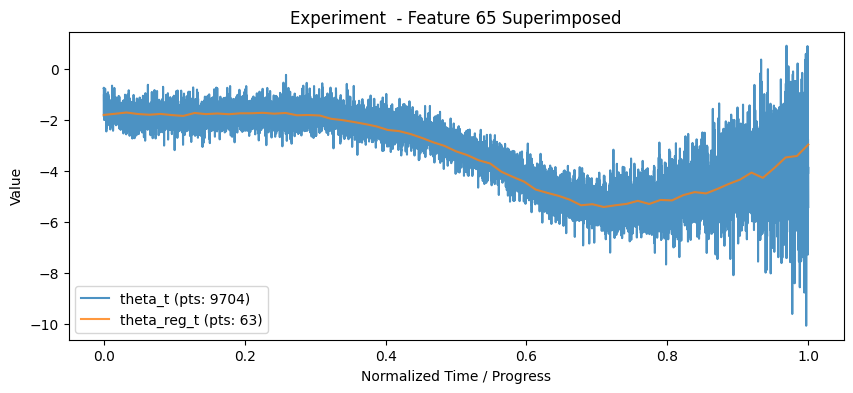

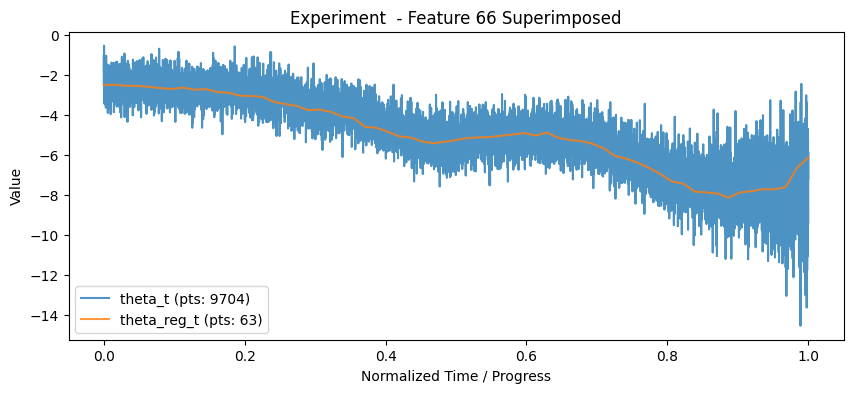

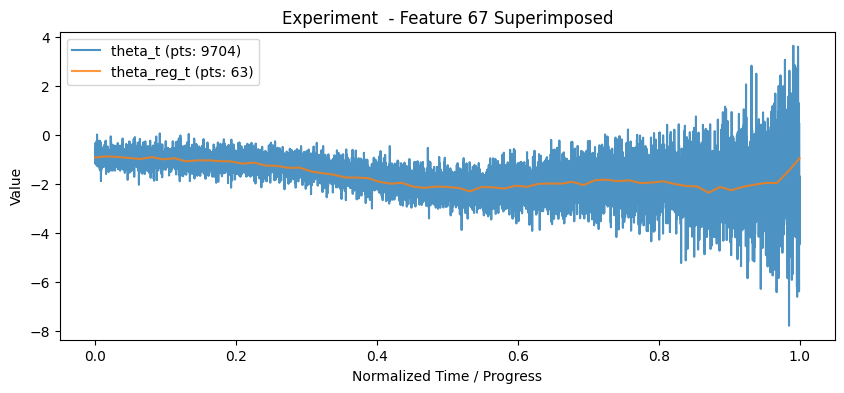

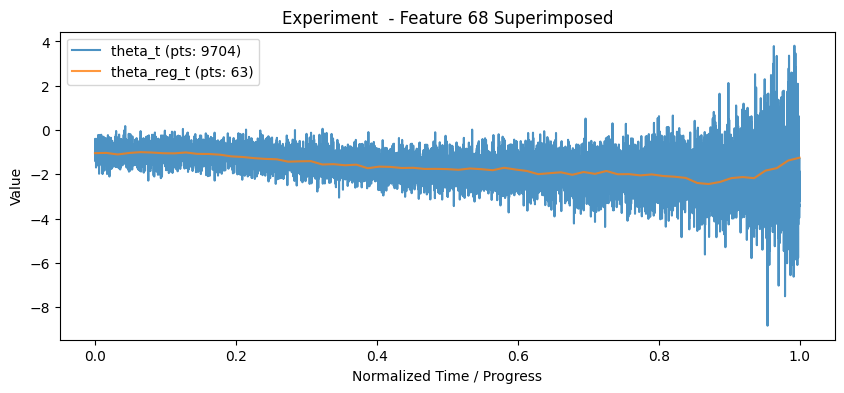

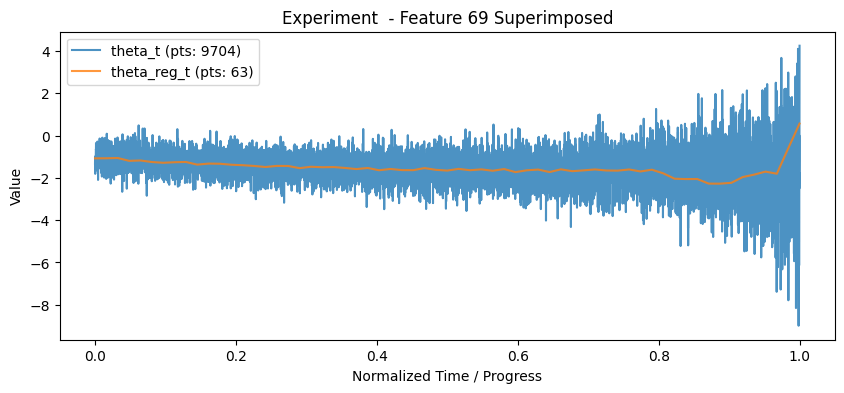

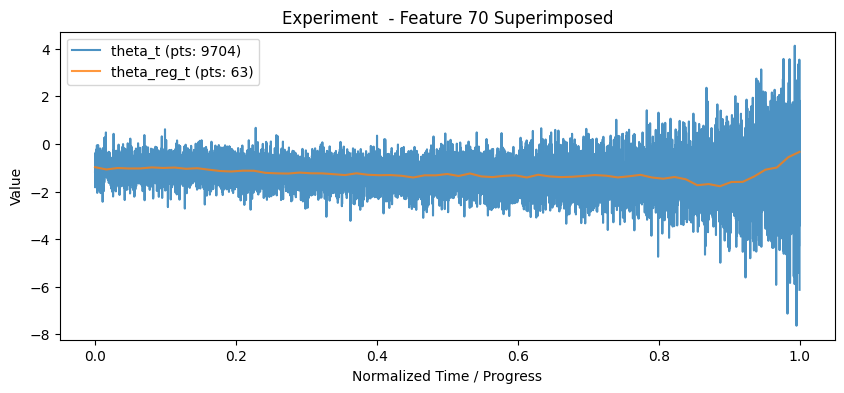

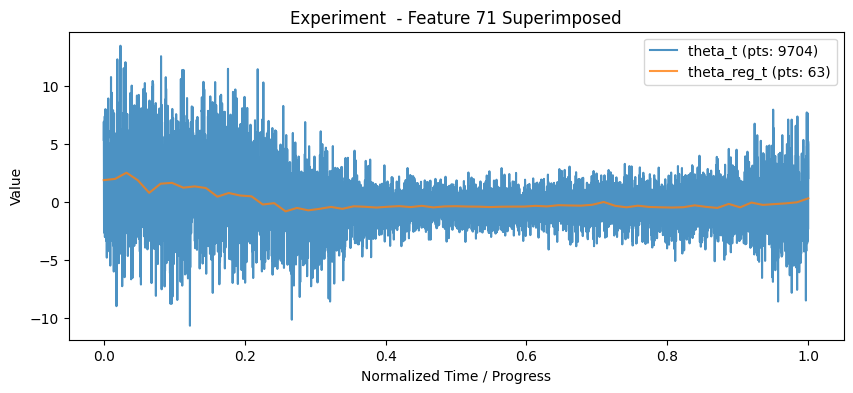

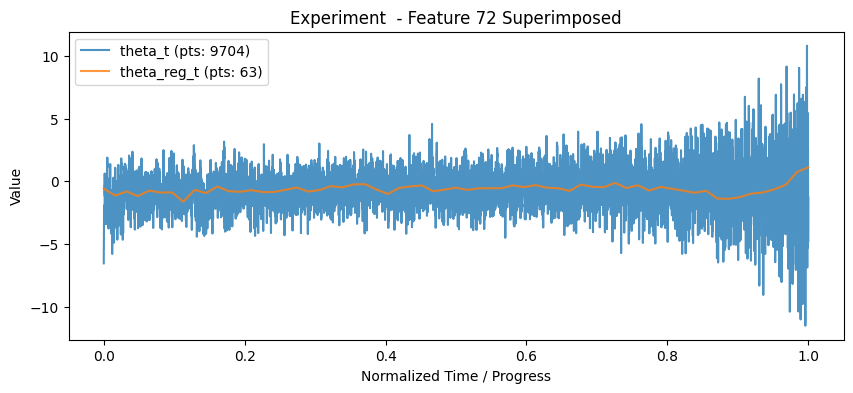

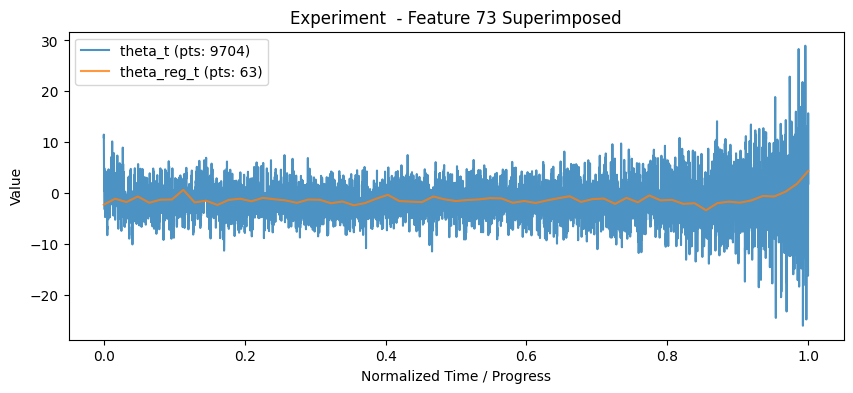

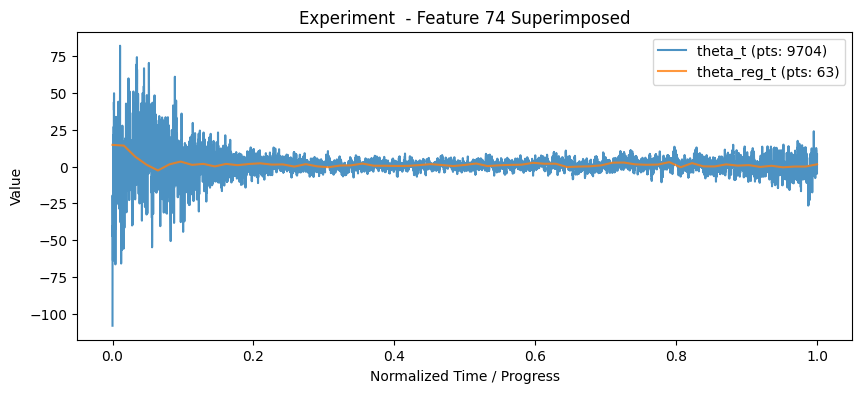

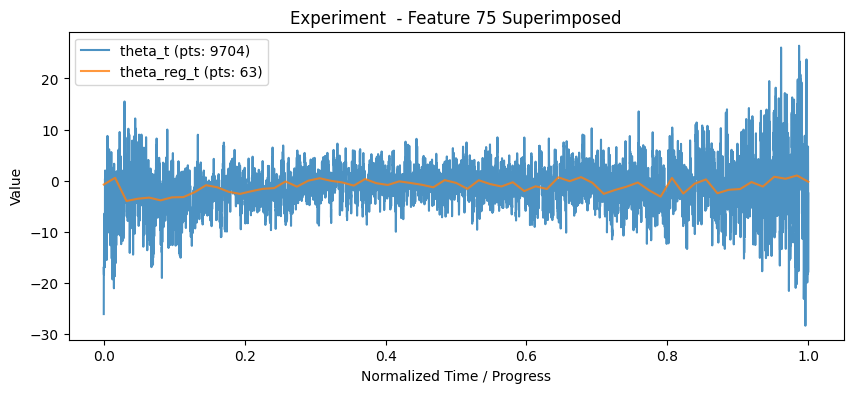

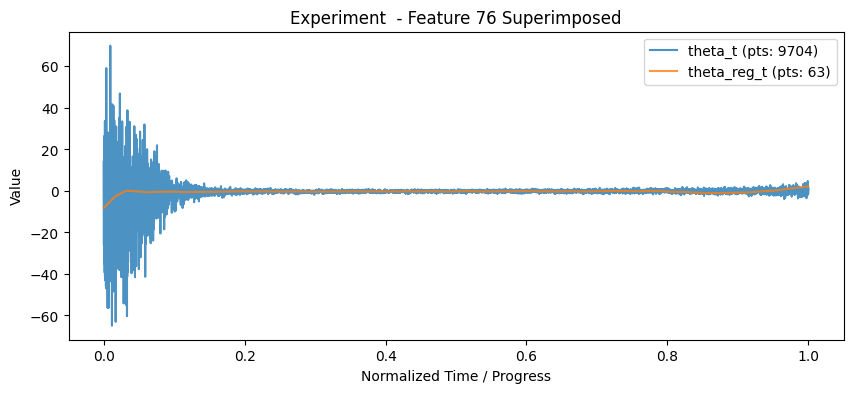

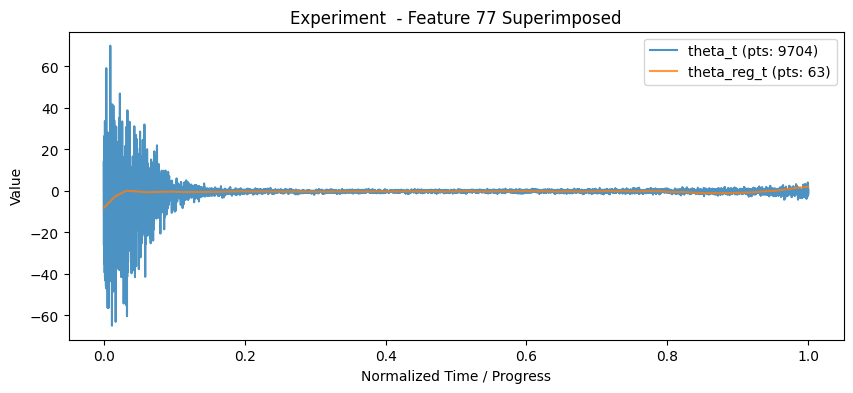

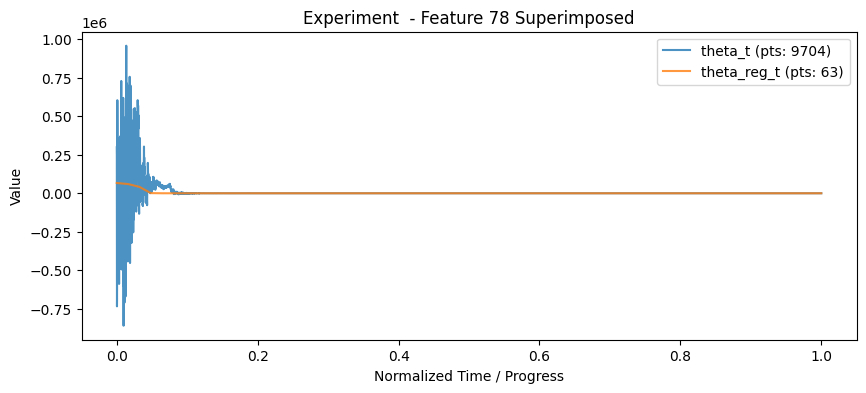

In [18]:
# Move to CPU and convert to numpy for easier plotting
import matplotlib.pyplot as plt
theta_t = theta_t.cpu()
theta_reg_t = theta_reg_t.cpu()

# Get the number of time steps (rows) for each
len_t = theta_t.shape[0]
len_reg = theta_reg_t.shape[0]
print(len_t, len_reg) 

# Iterate through each feature/column
%matplotlib inline
for i in range(theta_t.shape[1]): 
    # Create matching X-axes spanning from 0 to 1 (or 0 to len_t if preferred)
    x_t = np.linspace(0, 1, len_t)
    x_reg = np.linspace(0, 1, len_reg)
    
    plt.figure(figsize=(10, 4))
    
    # Plot both on the same axes
    #plt.plot(results[key]['xt'], theta_t[:, i], label=f"theta_t (pts: {len_t})", alpha=0.8) 
    plt.plot(x_t, theta_t[:, i], label=f"theta_t (pts: {len_t})", alpha=0.8) 
    plt.plot(x_reg, theta_reg_t[:, i], label=f"theta_reg_t (pts: {len_reg})", alpha=0.8) 
    
    plt.title(f"Experiment {label} - Feature {i} Superimposed")
    plt.xlabel("Normalized Time / Progress")
    plt.ylabel("Value")
    plt.legend()
    plt.show()  # Show the combined plot

## Moment matching diagnostics

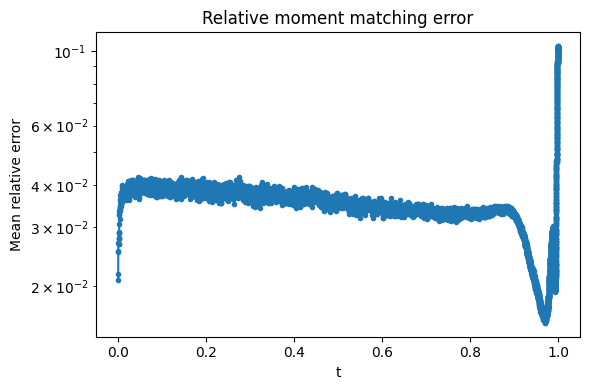

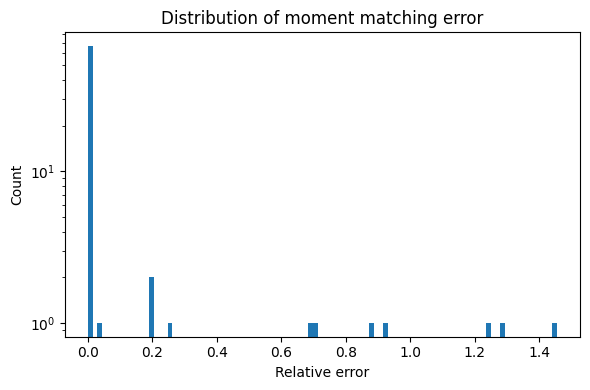

<Figure size 640x480 with 0 Axes>

In [19]:
threshold = 1e-8
%matplotlib inline
print(label)
if result.get('barphi_e') is None or result.get('barphi_p') is None:
    print('Moment matching arrays not available. Set FORCE_RERUN=True or make sure the auxiliary file exists.')
else:
    plot_moment_matching(result['barphi_e'], result['barphi_p'], result['t'], threshold)
    plt.suptitle(label)
    
    plt.show()


## Visual comparison of samples

In [30]:
def Compare_time_series_row(Data, Synth, N, save=None):
    """Compare the first N time series: data (top) vs synthesis (bottom)."""

    # Increased figure height slightly to accommodate larger labels without overlapping
    fig, axs = plt.subplots(
        2,
        N,
        figsize=(3.5 * N, 5.5),
        sharex=True,
        sharey=False,
        constrained_layout=True,
    )

    # Handle N=1 edge case where axs is 1D array instead of 2D
    if N == 1:
        axs = axs[:, np.newaxis]

    x = np.arange(Data.shape[-1])

    for row, (dataset, color, ylabel) in enumerate(
        zip((Data, Synth), ("tab:blue", "navy"), ("Data", "MGD synthesis"))
    ):

        # Row / Axis Title Font Size (16pt)
        axs[row, 0].set_ylabel(
            ylabel, fontsize=16, fontweight="bold", labelpad=8
        )

        for col, ax in enumerate(axs[row]):
            y = dataset[col, 0].cpu()
            ax.plot(
                x,
                y,
                color=color,
                lw=2.2,  # Thicker line for paper clarity
                marker="o",
                ms=3,  # Slightly larger marker
                mfc="white",
                mec=color,
                mew=1.0,
            )

            ax.grid(alpha=0.2)
            ax.spines[["top", "right"]].set_visible(False)

            if col:
                ax.set_yticklabels([])

            # Axis Tick Label Font Size (14pt)
            ax.tick_params(axis="both", which="major", labelsize=14)

    if save:
        if "title" in save:
            # Figure Title Font Size (18pt)
            fig.suptitle(save["title"], fontsize=18, fontweight="bold")
        fig.savefig(save["filename"], dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

In [31]:
for i in range(0,15): 
    save_config = {
        "filename": f"figures/jets_time_series_compare{i}.png",
        "title": ""  # Optional: set a title or leave out if not needed
    }
    print(result['xt'].shape) 
    print(label)
    Compare_time_series_row(x1[i*5:i*5+5,:,:], result['xt'][i*5:i*5+5,:,:],1, save_config)
    plt.suptitle(label)
    %matplotlib inline 
    plt.show()


torch.Size([2000, 1, 64])



<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 64])



<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 64])



...

<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 64])



<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 64])



<Figure size 640x480 with 0 Axes>

## Roba di boffetta

<Axes: xlabel='$\\tau$', ylabel='Skewness'>

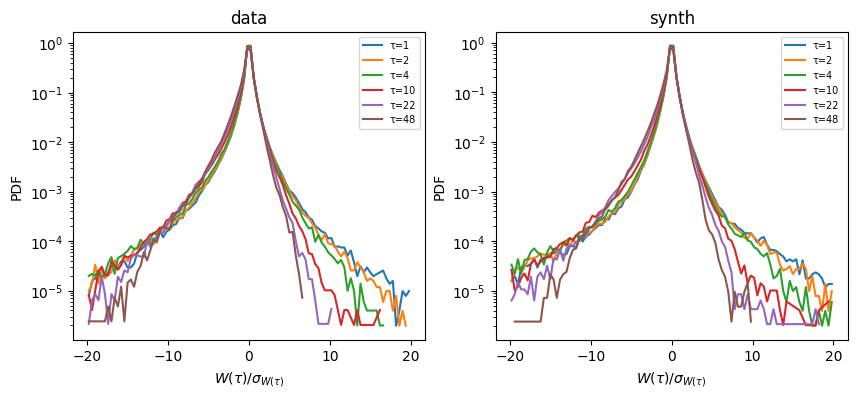

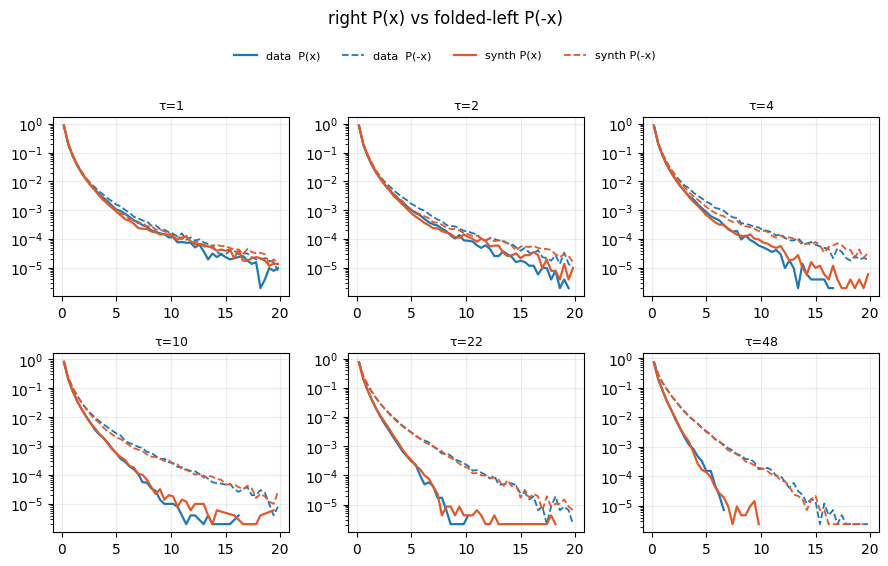

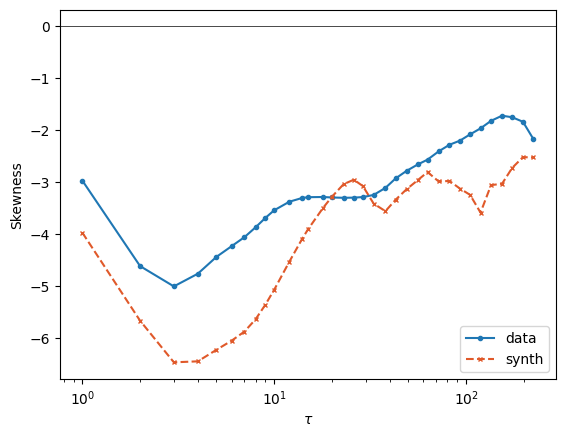

In [21]:
T = x1.shape[-1]
taus = logspaced_taus(50, num_points=6)              # positive only, for PDFs
pdf_data  = pdf_energy_increments(x1, taus, mode="power")
pdf_synth = pdf_energy_increments(result["xt"], taus, mode="power")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_pdf_panel(pdf_data, ax=axes[0], title="data")
plot_pdf_panel(pdf_synth, ax=axes[1], title="synth")

plot_pdf_folded_grid(pdf_data, pdf_synth, title="right P(x) vs folded-left P(-x)")

fig2, ax2 = plt.subplots()
%matplotlib inline
plot_skewness_comparison(x1, result["xt"], ax=ax2)   # positive-only log-x taus by default

## Energy increments distribution skewness 

In [107]:
# x = velocity 
E_data = 0.5 * x1**2 
E_synth = 0.5 * result["xt"]**2 

In [108]:
start_tau = 1      # The plot starts around tau = 2 or 3
end_tau = 1024     # The plot ends around 1000
num_points = 45    # Visually, there are roughly 40-50 points in the plot

# 2. Generate log-spaced floats using base-10 exponents
# log10(2) ≈ 0.301, log10(1000) = 3.0
taus_float = torch.logspace(
    start=torch.log10(torch.tensor(start_tau, dtype=torch.float32)),
    end=torch.log10(torch.tensor(end_tau, dtype=torch.float32)),
    steps=num_points,
    base=10.0
)

# 3. Convert to integers and keep only the unique values to prevent indexing errors
pos_taus = torch.unique(taus_float.long()).tolist()
neg_taus = [-t for t in reversed(pos_taus)]
taus_list = neg_taus + pos_taus

In [109]:
skew_data_array = []
skew_synth_array = []

for tau in taus_list: 
    # Gestione dello slicing per mantenere la coerenza temporale
    if tau > 0:
        # Il futuro v(t + tau) e il presente v(t)
        v_future_data = x1[:, :, tau:]
        v_present_data = x1[:, :, :-tau]
        
        v_future_synth = result["xt"][:, :, tau:]
        v_present_synth = result["xt"][:, :, :-tau]
    else:
        # Se tau è negativo (es. -5):
        # v(t + tau) è il passato -> x1[:, :, :-5]
        # v(t) è il presente -> x1[:, :, 5:]
        v_future_data = x1[:, :, :tau]
        v_present_data = x1[:, :, -tau:]
        
        v_future_synth = result["xt"][:, :, :tau]
        v_present_synth = result["xt"][:, :, -tau:]

    # 1. Calcola l'incremento di velocità corretto: delta_v = v(t + tau) - v(t)
    delta_v_data = v_future_data - v_present_data
    delta_v_synth = v_future_synth - v_present_synth
    
    # 2. Moltiplica l'incremento per la velocità presente v(t)
    target_data = delta_v_data * v_present_data
    target_synth = delta_v_synth * v_present_synth
    
    # 3. Centra i dati rispetto alla media
    target_data_centered = target_data - torch.mean(target_data)
    target_synth_centered = target_synth - torch.mean(target_synth)
    
    # 4. Calcola la skewness: S = < target^3 > / < target^2 >^1.5
    skew_data = (torch.mean(target_data_centered**3) / (torch.mean(target_data_centered**2)**1.5)).cpu()
    skew_synth = (torch.mean(target_synth_centered**3) / (torch.mean(target_synth_centered**2)**1.5)).cpu()
    
    skew_data_array.append(skew_data.item()) 
    skew_synth_array.append(skew_synth.item())

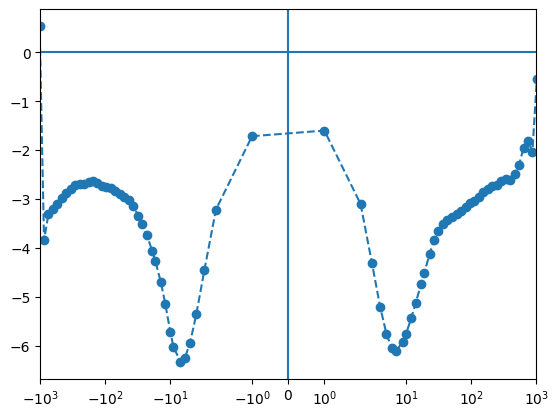

In [110]:
plt.plot(taus_list, skew_data_array, "o--") 
#plt.plot(taus_list, skew_synth_array, "o--") 
plt.axhline(0)
plt.axvline(0) 
plt.xscale("symlog") 
plt.xlim(-1000, 1000)
plt.show() 

## Leverage with C_pq

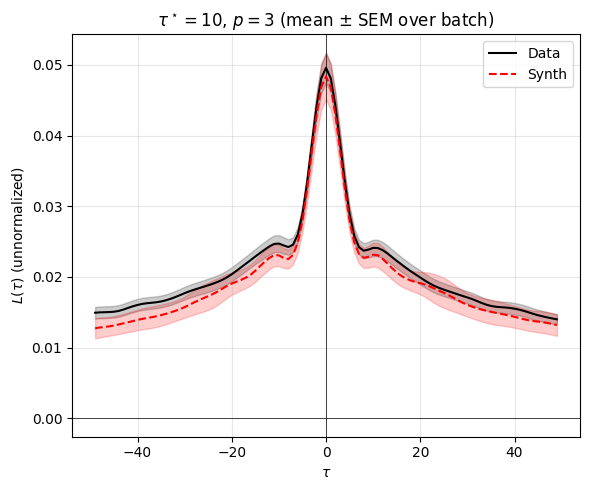

In [11]:
tau, L_data, err_data, L_synth, err_synth = C_pq_plot(x1, result["xt"], p = 3.0, tau_star=10, normalize=False) 

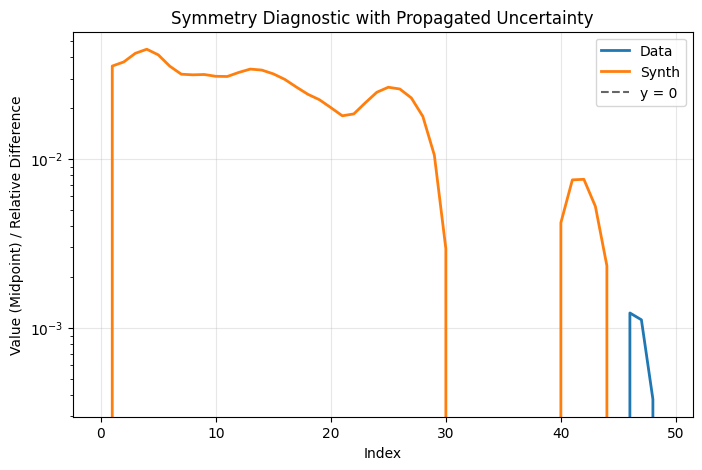

In [22]:
# 2. Find the midpoint index
half = L_data.shape[0] // 2 

# --- Rel Diff: DATA ---
A_d, B_d = L_data[:half], L_data[-half:][::-1]
sA_d, sB_d = err_data[:half], err_data[-half:][::-1]

rel_diff_data = (-1*A_d + B_d) / ((A_d + B_d) / 2)
# Propagated error for relative difference
err_rel_diff_data = (4 / (A_d + B_d)**2) * np.sqrt((B_d * sA_d)**2 + (A_d * sB_d)**2)

# --- Rel Diff: SYNTHETIC ---
A_s, B_s = L_synth[:half], L_synth[-half:][::-1]
sA_s, sB_s = err_synth[:half], err_synth[-half:][::-1]

rel_diff_synth = (-1*A_s + B_s) / ((A_s + B_s) / 2)
# Propagated error for relative difference
err_rel_diff_synth = (4 / (A_s + B_s)**2) * np.sqrt((B_s * sA_s)**2 + (A_s * sB_s)**2)

# 3. Prepend the midpoint value and its original error (index 0)
diff_data = np.r_[0, rel_diff_data]
diff_synth = np.r_[0, rel_diff_synth]

err_plot_data = np.r_[err_data[half], err_rel_diff_data]
err_plot_synth = np.r_[err_synth[half], err_rel_diff_synth]

# 4. Plotting
plt.figure(figsize=(8, 5))
x_axis = np.arange(len(diff_data))

# Plot lines
plt.plot(x_axis, diff_data, label="Data", color="C0", lw=2)
plt.plot(x_axis, diff_synth, label="Synth", color="C1", lw=2)

# Plot uncertainty bounds
# plt.fill_between(x_axis, diff_data - err_plot_data, diff_data + err_plot_data, 
#                  color="C0", alpha=0.2, label="Data Uncertainty")
# plt.fill_between(x_axis, diff_synth - err_plot_synth, diff_synth + err_plot_synth, 
#                  color="C1", alpha=0.2, label="Synth Uncertainty")

# Reference line at y=0 (dashed, thin)
plt.axhline(0, color="black", linestyle="--", alpha=0.6, label="y = 0")

plt.yscale("log") 
plt.xlabel("Index")
plt.ylabel("Value (Midpoint) / Relative Difference")
plt.title("Symmetry Diagnostic with Propagated Uncertainty")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Scaling exponent ratio 

Computing structure functions for 24 lags...
Computing structure functions for 24 lags...


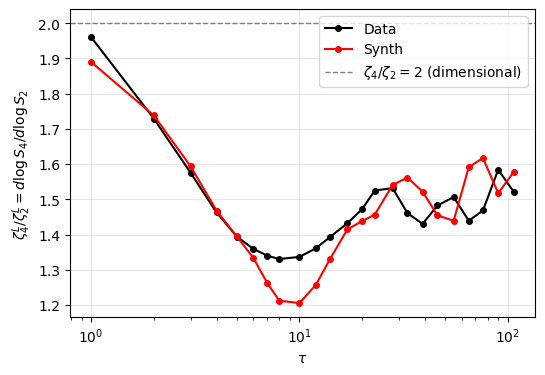

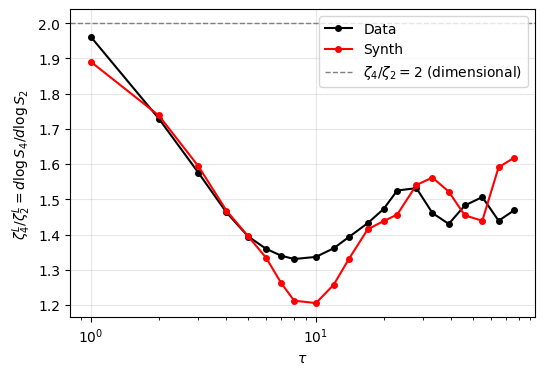

In [23]:
taus, ratio_data, ratio_synth = scaling_exponent_ratio_compare(x1, result['xt'], 30, kill_points=1) 

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(taus[:-2], ratio_data[:-2], 'ko-', ms=4, label='Data')
ax.plot(taus[:-2], ratio_synth[:-2], 'ro-', ms=4, label='Synth')
ax.axhline(2.0, color='grey', ls='--', lw=1, label=r'$\zeta_4/\zeta_2=2$ (dimensional)')
ax.set_xscale('log')
ax.set_xlabel(r'$\tau$')
ax.set_ylabel(r'$\zeta_4^L/\zeta_2^L = d\log S_4 / d\log S_2$')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Histograms reproduction and other diagnostics 

Spectrum



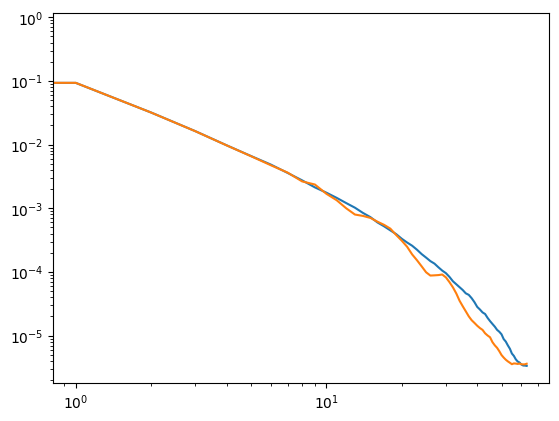

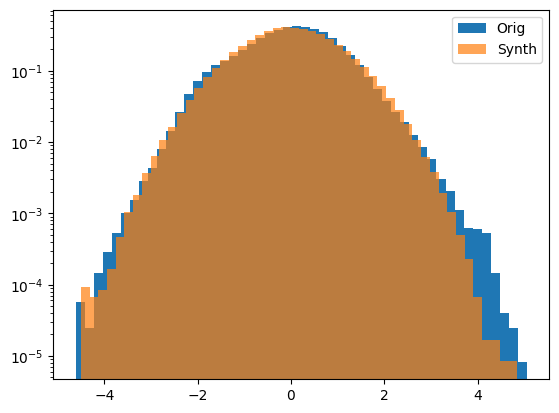

<Figure size 640x480 with 0 Axes>

Histogram



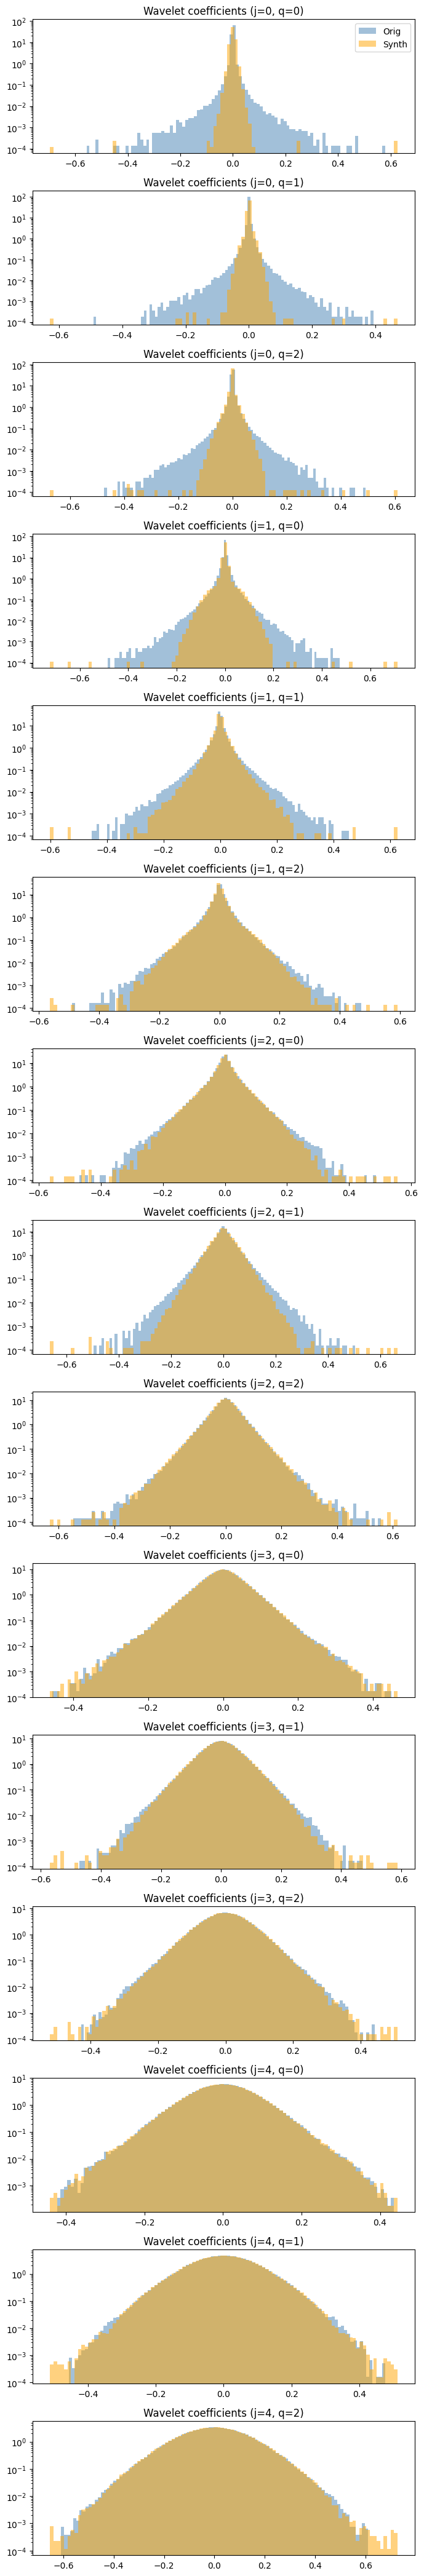

<Figure size 640x480 with 0 Axes>

Structure functions

Loaded structure functions from cache!
Computing structure functions for 63 lags...


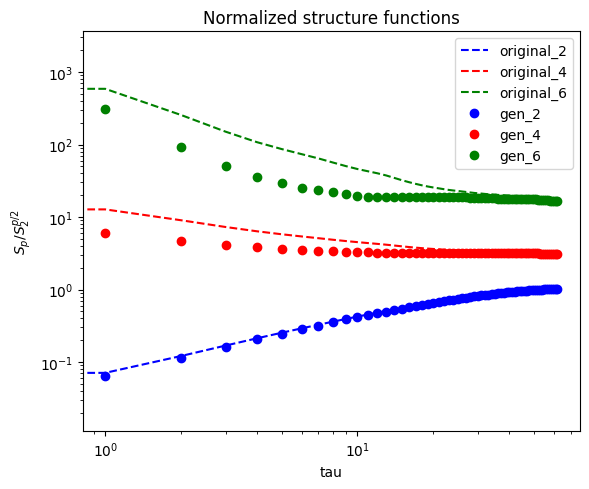

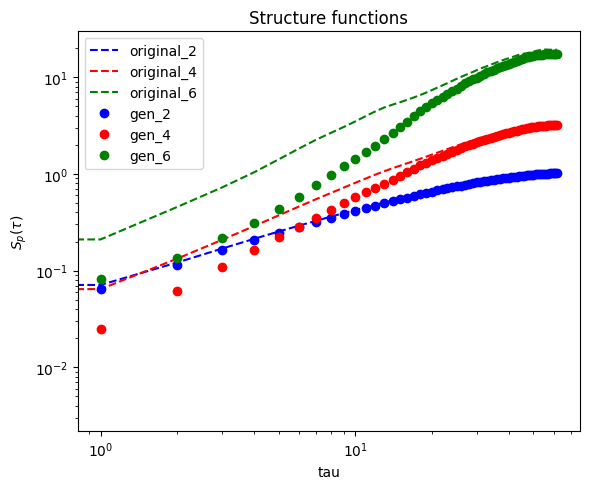

<Figure size 640x480 with 0 Axes>

In [20]:
%matplotlib inline 
def run_project_diagnostics(x_ref, result):
    """
    Uses the existing project plotting utilities. These functions usually create
    their own figures, so we call each diagnostic once per model and add titles.
    """
    diagnostic_functions = [
        ('Spectrum', spec_plot),
        ('Histogram', hist_plot),
        ('Structure functions', structure_plot),
    ]

    for diag_name, diag_fun in diagnostic_functions:
        print('' + '=' * 80)
        print(diag_name)
        print('=' * 80)
        print(label)
        diag_fun(x_ref, result['xt'])
        plt.suptitle(f"{diag_name}: {label}")
        plt.show()

    #print('' + '=' * 80)
    #print('Cross statistics')
    #print('=' * 80)
    #for key, exp in experiments.items():
        #print(exp['label'])
        #cross_plot(x_ref, xt_cg, pq=[(3, 1), (3, 3), (4, 4)])
        #plt.suptitle(f"Cross statistics: {exp['label']}")
        #plt.show()

run_project_diagnostics(x1, result)


## Entropy bound comparison

Contains NaN: tensor(False)
Contains Inf: tensor(False)
GaussianK_psi
  Entropy bound: 47.57743835449219
  Gaussian estimation: -66.50381469726562


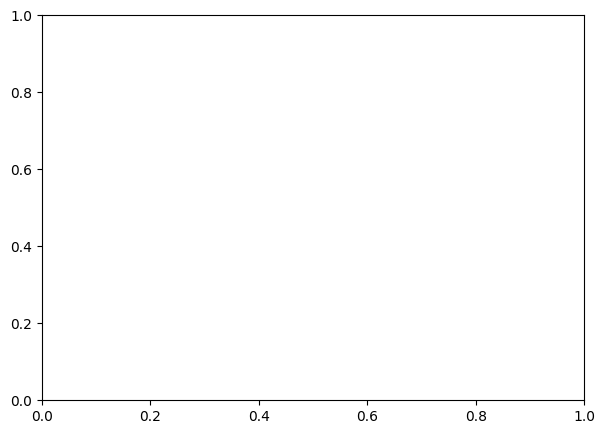

<class 'ValueError'>: x and y must have same first dimension, but have shapes (41,) and (39,)

In [30]:
def entropy_curves(x_ref, dH_t_bound, t_used):
    d = x_ref.shape[-2] * x_ref.shape[-1]
    H_p_0 = (np.log(2 * np.pi) + 1) * d / 2
    H_t_bound = dH_t_bound.cumsum(0).detach().cpu() / (t_used.shape[0]) + H_p_0
    H_t_gaussian = compute_gaussian_entropy(x_ref, interpolant, t_used)
    return H_t_bound, H_t_gaussian

plt.figure(figsize=(7, 5))
last_gaussian = None

H_t_bound, H_t_gaussian = entropy_curves(x1, result['dH_t_bound'], result['t'].cpu())

print("Contains NaN:", torch.isnan(result['dH_t_bound']).any())
print("Contains Inf:", torch.isinf(result['dH_t_bound']).any())
last_gaussian = H_t_gaussian
print(label)
print('  Entropy bound:', H_t_bound[-2].item() if torch.is_tensor(H_t_bound[-2]) else H_t_bound[-1])
print('  Gaussian estimation:', H_t_gaussian[-2].item() if torch.is_tensor(H_t_gaussian[-2]) else H_t_gaussian[-2])
plt.plot(result['t'].detach().cpu(), H_t_bound, label=f"bound: {label}")
"""
plt.plot(
    t.detach().cpu(),
    last_gaussian.detach().cpu() if torch.is_tensor(last_gaussian) else last_gaussian,
    '--',
    label='Gaussian entropy estimate',
)
plt.xlabel('t')
plt.ylabel('entropy')
plt.legend()
plt.tight_layout()
plt.show()
"""

## Project entropy plotting utility for each model